### Import Libraries and data

In [25]:
import pandas as pd
import numpy as np
import warnings
warnings.filterwarnings('ignore')

In [26]:
def reduce_mem_usage(df):

    start_mem = df.memory_usage().sum() 
    print('Memory usage of dataframe is {:.2f} MB'.format(start_mem))
    
    for col in df.columns:
        col_type = df[col].dtype
        
        if col_type != object:
            c_min = df[col].min()
            c_max = df[col].max()
            if str(col_type)[:3] == 'int':
                if c_min > np.iinfo(np.int8).min and c_max < np.iinfo(np.int8).max:
                    df[col] = df[col].astype(np.int8)
                elif c_min > np.iinfo(np.int16).min and c_max < np.iinfo(np.int16).max:
                    df[col] = df[col].astype(np.int16)
                elif c_min > np.iinfo(np.int32).min and c_max < np.iinfo(np.int32).max:
                    df[col] = df[col].astype(np.int32)
                elif c_min > np.iinfo(np.int64).min and c_max < np.iinfo(np.int64).max:
                    df[col] = df[col].astype(np.int64)  
            else:
                if c_min > np.finfo(np.float16).min and c_max < np.finfo(np.float16).max:
                    df[col] = df[col].astype(np.float16)
                elif c_min > np.finfo(np.float32).min and c_max < np.finfo(np.float32).max:
                    df[col] = df[col].astype(np.float32)
                else:
                    df[col] = df[col].astype(np.float64)
        else:
            df[col] = df[col].astype('category')

    end_mem = df.memory_usage().sum() 
    print('Memory usage after optimization is: {:.2f} MB'.format(end_mem))
    print('Decreased by {:.1f}%'.format(100 * (start_mem - end_mem) / start_mem))
    return df

In [27]:
sample_feature = reduce_mem_usage(pd.read_csv('data_for_tree.csv'))

Memory usage of dataframe is 63691972.00 MB
Memory usage after optimization is: 17117446.00 MB
Decreased by 73.1%


In [28]:
continuous_feature_names = [x for x in sample_feature.columns if x not in ['price','brand','model','brand']]

In [29]:
# for package auto reload
%load_ext autoreload
%autoreload 2

# for better rendering of plots in jupyter notebook
%matplotlib inline

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [30]:
# base modules
from pathlib import Path
import logging
from collections import OrderedDict

# for manipulating data
import numpy as np
import pandas as pd
import math

# for Machine Learning
from sklearn.ensemble import RandomForestRegressor, BaggingRegressor
from sklearn.tree import DecisionTreeRegressor, plot_tree
from sklearn import metrics
from sklearn.model_selection import cross_val_score, KFold, GridSearchCV

# for visualization
from matplotlib import pyplot as plt

In [31]:
from typing import Callable
import copy
import re
import numpy as np
import pandas as pd
from pandas.api.types import is_string_dtype, is_numeric_dtype
def process_df(
    df: pd.DataFrame, 
    y_field: str | None = None, 
    skip_flds: list = [],
    ignore_flds: list = [], 
    na_dict: dict = {},
    preproc_fn: Callable = None, 
    max_n_cat = None, 
    ):
    """
    Take a dataframe df and splits off the response variable, and
    changes the df into an entirely numeric dataframe. For each column of df 
    which is not in skip_flds nor in ignore_flds, na values are replaced by the
    median value of the column.
    """
    df = copy.deepcopy(df)
    
    df_ignored = df.loc[:, ignore_flds]
    df = df.drop(columns = ignore_flds)
    
    if preproc_fn: 
        preproc_fn(df)
        
    if y_field is None: 
        y = None
    else:
        if not is_numeric_dtype(df[y_field]): 
            df[y_field] = pd.Categorical(df[y_field]).codes
        y = df[y_field].values
        skip_flds += [y_field]
    
    df = df.drop(columns = skip_flds)

    na_dict_initial = na_dict.copy()
    for n, c in df.items(): 
        na_dict = fix_missing(df, c, n, na_dict)
    
    if len(na_dict_initial) > 0:
        df = df.drop(
            [a + '_na' for a in list(set(na_dict.keys()) - set(na_dict_initial.keys()))], 
            axis = 1,
        )
    for n,c in df.items(): 
        df = numericalize(df, c, n, max_n_cat)
        
    df = pd.get_dummies(df, dummy_na = True)
    df = pd.concat([df_ignored, df], axis = 1)
    return (df, y, na_dict)


In [32]:
def fix_missing(df, col, name, na_dict):
    """
    Fill missing data in a column of df with the median, and add a {name}_na column
    which specifies if the data was missing.
    """
    if is_numeric_dtype(col):
        if pd.isnull(col).sum() or (name in na_dict):
            df[name + '_na'] = pd.isnull(col)
            filler = na_dict[name] if name in na_dict else col.median()
            df[name] = col.fillna(filler)
            na_dict[name] = filler
    return na_dict

    
def numericalize(df: pd.DataFrame, col: str, name: str, max_n_cat: int | None) -> pd.DataFrame:
    """
    Changes the column col from a categorical type to it's integer codes.
    """
    df = copy.deepcopy(df)
    if (not is_numeric_dtype(col) 
        and (max_n_cat is None or len(col.cat.categories) > max_n_cat)):
        df[name] = pd.Categorical(col).codes + 1
    return df

In [33]:
df, y, nas = process_df(sample_feature, 'price')

In [34]:
print(df.shape)
df.head()

(199037, 48)


,SaleID,name,model,brand,bodyType,fuelType,gearbox,power,kilometer,notRepairedDamage,...,power_bin,model_na,bodyType_na,fuelType_na,gearbox_na,train_na,test_na,used_time_na,city_na,power_bin_na
0,0,736,30.0,6,1.0,0.0,0.0,60,12.5,2,...,5.0,False,False,False,False,False,True,False,False,False
1,1,2262,40.0,1,2.0,0.0,0.0,0,15.0,1,...,11.0,False,False,False,False,False,True,False,False,True
2,2,14874,115.0,15,1.0,0.0,0.0,163,12.5,2,...,16.0,False,False,False,False,False,True,False,False,False
3,3,71865,109.0,10,0.0,0.0,1.0,193,15.0,2,...,19.0,False,False,False,False,False,True,False,True,False
4,4,111080,110.0,5,1.0,0.0,0.0,68,5.0,2,...,6.0,False,False,False,False,False,True,False,False,False


In [35]:
len(y)
y

array([1850., 3600., 6222., ...,   nan,   nan,   nan],
      shape=(199037,), dtype=float32)

In [36]:
import numpy as np
import pandas as pd

# 假设 y 可能是 Series 或 ndarray
y = pd.to_numeric(y, errors='coerce')  # 把非数值强制转 NaN

# 如果是 ndarray，则用 np.isnan 来处理掩码
if isinstance(y, np.ndarray):
    mask = ~np.isnan(y)
else:
    mask = y.notna()

# 过滤掉 y 的缺失样本
X = df.loc[mask].copy()
y = y[mask].astype(float).ravel()

# 处理 X 中可能残留的 NaN
if X.isna().any().any():
    X = X.fillna(X.median(numeric_only=True))

In [37]:
y_series = pd.to_numeric(pd.Series(y), errors='coerce')
mask = y_series.notna()

X = X.loc[mask].copy()
y = y_series.loc[mask].astype(float).to_numpy().ravel()

# 2) 若 X 仍有 NaN（比如有 skip_flds），再做一次填补
if X.isna().any().any():
    X = X.fillna(X.median(numeric_only=True))

# 3) 训练前自检
print("X rows:", X.shape[0], "y rows:", y.shape[0], "X cols:", X.shape[1])
assert X.shape[0] == y.shape[0]

# 4) 训练（注意用 X，不是原 df）
model = RandomForestRegressor(n_estimators=200, n_jobs=-1, random_state=42)
model.fit(X, y)

X rows: 149037 y rows: 149037 X cols: 48


,n_estimators,200
,criterion,'squared_error'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,1.0
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


In [38]:
x = df.iloc[0]
y_true = np.exp(y[0])
x, y_true

(SaleID                          0
 name                          736
 model                        30.0
 brand                           6
 bodyType                      1.0
 fuelType                      0.0
 gearbox                       0.0
 power                          60
 kilometer                    12.5
 notRepairedDamage               2
 seller                          0
 offerType                       0
 v_0                      43.34375
 v_1                      3.966797
 v_2                      0.050262
 v_3                      2.160156
 v_4                      1.143555
 v_5                      0.235718
 v_6                       0.10199
 v_7                      0.129517
 v_8                      0.022812
 v_9                      0.097473
 v_10                    -2.880859
 v_11                     2.804688
 v_12                    -2.419922
 v_13                      0.79541
 v_14                     0.914551
 train                         1.0
 test               

In [39]:
x = [x]                   # wrap the data point into a list
y_pred = model.predict(x) # prediction, as list
y_pred = y_pred[0]        # take first element of predicted list
y_pred = np.exp(y_pred)   # exponentialize
y_pred

np.float64(inf)

In [40]:
model.score(X, y)

0.9950527226149228

In [41]:
n_total = len(df)
n_valid = 50000      
n_small = 60000      # 小样本集大小（快速实验）
n_train = n_total - n_valid

In [42]:
def split_vals(df: pd.DataFrame, n: int) -> pd.DataFrame: 
    return df[:n].copy(), df[n:].copy()

In [43]:
X_train, X_valid = split_vals(df, n_train)
y_train, y_valid = split_vals(y, n_train)

X_small, _ = split_vals(X_train, n_small)
y_small, _ = split_vals(y_train, n_small)

print('Number of small training data points: X = {}, y = {}'.format(X_small.shape, y_small.shape))
print('Number of full training data points: X = {}, y = {}'.format(X_train.shape, y_train.shape))
print('Number of validation data points: X = {}, y = {}'.format(X_valid.shape, y_valid.shape))

Number of small training data points: X = (60000, 48), y = (60000,)
Number of full training data points: X = (149037, 48), y = (149037,)
Number of validation data points: X = (50000, 48), y = (0,)


In [44]:
n_total   = len(df)          
n_test= n_total - len(y)  
X_labeled = df.iloc[: n_total - n_test].copy() 


# ---------- 2) 在“有标签段”里做最简单切分 ----------
n_valid = 12000          # 老师例子
n_train = len(X_labeled) - n_valid

def split_vals(a, n):
    return a[:n].copy(), a[n:].copy()

X_train, X_valid = split_vals(X_labeled, n_train)
y_train, y_valid = split_vals(y,          n_train)

In [45]:
def rmse(y_gold, y_pred): 
    return math.sqrt(((y_gold - y_pred)**2).mean())

In [46]:
def print_score(m, X_train, y_train, X_valid, y_valid):
    print('RMSE on train set: {:.4f}'.format(rmse(m.predict(X_train), y_train)))
    print('RMSE on valid set: {:.4f}'.format(rmse(m.predict(X_valid), y_valid)))
    print('R^2 on train set: {:.4f}'.format(m.score(X_train, y_train)))
    print('R^2 on valid set: {:.4f}'.format(m.score(X_valid, y_valid)))
    if hasattr(m, 'oob_score_'): print('R^2 on oob set: {:.4f}'.format(m.oob_score_))
    return

In [47]:
base_model = RandomForestRegressor(n_estimators=10, n_jobs=-1, random_state=42)
base_model.fit(X_small, y_small)
print_score(base_model, X_small, y_small, X_valid, y_valid)

RMSE on train set: 628.2214
RMSE on valid set: 1488.8488
R^2 on train set: 0.9918
R^2 on valid set: 0.9542


In [48]:
base_model = RandomForestRegressor(n_estimators = 10, n_jobs = -1, random_state = 42)

%time base_model.fit(X_train, y_train)
print_score(base_model, X_train, y_train, X_valid, y_valid)

CPU times: total: 42.5 s
Wall time: 6.64 s
RMSE on train set: 610.5800
RMSE on valid set: 1481.9888
R^2 on train set: 0.9924
R^2 on valid set: 0.9547


In [49]:
model_dt = DecisionTreeRegressor(
    criterion = 'squared_error',
    splitter = 'best', 
    max_depth = 3,
    min_samples_split = 2, 
    min_samples_leaf = 1,
    min_weight_fraction_leaf = 0.0, 
    max_features = None, 
    max_leaf_nodes = None, 
    min_impurity_decrease = 0.0, 
    ccp_alpha = 0.0,
    random_state = 42, 
)

In [50]:
%time model_dt.fit(X_small, y_small)
print_score(model_dt, X_small, y_small, X_valid, y_valid)

CPU times: total: 344 ms
Wall time: 316 ms
RMSE on train set: 2908.8824
RMSE on valid set: 3036.8245
R^2 on train set: 0.8251
R^2 on valid set: 0.8096


In [51]:
model_dt = DecisionTreeRegressor(
    criterion = 'squared_error',
    splitter = 'best', 
    max_depth = 15,
    min_samples_split = 2, 
    min_samples_leaf = 1,
    min_weight_fraction_leaf = 0.0, 
    max_features = None, 
    max_leaf_nodes = None, 
    min_impurity_decrease = 0.0, 
    ccp_alpha = 0.0,
    random_state = 42,
)

In [52]:
%time model_dt.fit(X_small, y_small)
print_score(model_dt, X_small, y_small, X_valid, y_valid)

CPU times: total: 1.62 s
Wall time: 1.65 s
RMSE on train set: 625.8119
RMSE on valid set: 2039.4831
R^2 on train set: 0.9919
R^2 on valid set: 0.9141


In [53]:
model_dt = DecisionTreeRegressor(
    criterion = 'squared_error',
    splitter = 'best', 
    max_depth = 15,
    min_samples_split = 2, 
    min_samples_leaf = 1,
    min_weight_fraction_leaf = 0.0, 
    max_features = None, 
    max_leaf_nodes = None, 
    min_impurity_decrease = 0.0001, 
    ccp_alpha = 0.0,
    random_state = 42,
)

In [54]:
%time model_dt.fit(X_small, y_small)
print_score(model_dt, X_small, y_small, X_valid, y_valid)

CPU times: total: 1.61 s
Wall time: 1.65 s
RMSE on train set: 625.8119
RMSE on valid set: 2039.4830
R^2 on train set: 0.9919
R^2 on valid set: 0.9141


In [55]:
model_dt = DecisionTreeRegressor(
    criterion = 'squared_error',
    splitter = 'best', 
    max_depth = 3,
    min_samples_split = 2, 
    min_samples_leaf = 1,
    min_weight_fraction_leaf = 0.0, 
    max_features = None, 
    max_leaf_nodes = None, 
    min_impurity_decrease = 0.0, 
    ccp_alpha = 0.0,
    random_state = 42,
)

In [56]:
%time model_dt.fit(X_small, y_small)
print_score(model_dt, X_small, y_small, X_valid, y_valid)

CPU times: total: 328 ms
Wall time: 332 ms
RMSE on train set: 2908.8824
RMSE on valid set: 3036.8245
R^2 on train set: 0.8251
R^2 on valid set: 0.8096


In [57]:
import re
import IPython
import graphviz
from sklearn.base import ClassifierMixin
from sklearn.tree import export_graphviz
import matplotlib.pyplot as plt


def set_plot_sizes(sml: int, med: int, big: int) -> None:
    plt.rc('font', size = sml)          # controls default text sizes
    plt.rc('axes', titlesize = sml)     # fontsize of the axes title
    plt.rc('axes', labelsize = med)     # fontsize of the x and y labels
    plt.rc('xtick', labelsize = sml)    # fontsize of the tick labels
    plt.rc('ytick', labelsize = sml)    # fontsize of the tick labels
    plt.rc('legend', fontsize = sml)    # legend fontsize
    plt.rc('figure', titlesize = big)   # fontsize of the figure title
    return

    
def draw_tree(
    tree: ClassifierMixin, 
    feature_names: list[str], 
    size: int = 10, 
    ratio: float = 0.6, 
    precision: int = 0,
    ):
    """
    Draws a representation of a random forest in IPython.
    """
    s = export_graphviz(
        tree, 
        out_file = None, 
        feature_names = feature_names, 
        filled = True, 
        special_characters = True, 
        rotate = True, 
        precision = precision,
    )
    # return s
    IPython.display.display(
        graphviz.Source(re.sub('Tree {', f'Tree {{ size={size}; ratio={ratio}', s))
    )

In [58]:
fig, axes = plt.subplots(nrows = 1, ncols = 1, figsize = (15, 10), dpi = 300)
plot_tree(model_dt, filled = True)

[Text(0.5, 0.875, 'x[12] <= 46.516\nsquared_error = 48367526.881\nsamples = 60000\nvalue = 5752.978'),
 Text(0.25, 0.625, 'x[15] <= -0.725\nsquared_error = 10729296.471\nsamples = 49756\nvalue = 3493.891'),
 Text(0.375, 0.75, 'True  '),
 Text(0.125, 0.375, 'x[24] <= 1.981\nsquared_error = 11203124.56\nsamples = 12674\nvalue = 7483.353'),
 Text(0.0625, 0.125, 'squared_error = 5336603.168\nsamples = 8566\nvalue = 6083.292'),
 Text(0.1875, 0.125, 'squared_error = 10825698.828\nsamples = 4108\nvalue = 10402.761'),
 Text(0.375, 0.375, 'x[12] <= 44.422\nsquared_error = 3268380.11\nsamples = 37082\nvalue = 2130.36'),
 Text(0.3125, 0.125, 'squared_error = 1104152.219\nsamples = 25664\nvalue = 1417.748'),
 Text(0.4375, 0.125, 'squared_error = 4425941.462\nsamples = 11418\nvalue = 3732.084'),
 Text(0.75, 0.625, 'x[24] <= 3.997\nsquared_error = 85994151.906\nsamples = 10244\nvalue = 16725.558'),
 Text(0.625, 0.75, '  False'),
 Text(0.625, 0.375, 'x[24] <= 2.487\nsquared_error = 33648293.478\nsamp

In [59]:
# --- drop-in 替代：与原用法同名，同参数 ---
import matplotlib.pyplot as plt
from sklearn.tree import plot_tree as _plot_tree

def draw_tree(model_dt, feature_names=None, precision=3,
              max_depth=3,  # 画太深会挤在一起，默认先限制层数，可改大或设为 None
              filename=None, dpi=200, figsize=(22, 10)):
    """
    兼容版本的 draw_tree：保持你原来的写法，但不再依赖 Graphviz。
    - model_dt: 已训练的 DecisionTree* 模型
    - feature_names: 列名列表
    - precision: 小数位显示
    - max_depth: 显示的最大层数（可设 None 全部显示）
    - filename: 若提供则保存 PNG
    """
    fig = plt.figure(figsize=figsize)
    ax = plt.gca()
    _plot_tree(
        model_dt,
        feature_names=feature_names,
        filled=True,
        rounded=True,
        precision=precision,
        max_depth=max_depth,
        ax=ax
    )
    plt.tight_layout()
    if filename:
        fig.savefig(filename, dpi=dpi, bbox_inches="tight")
    return fig 



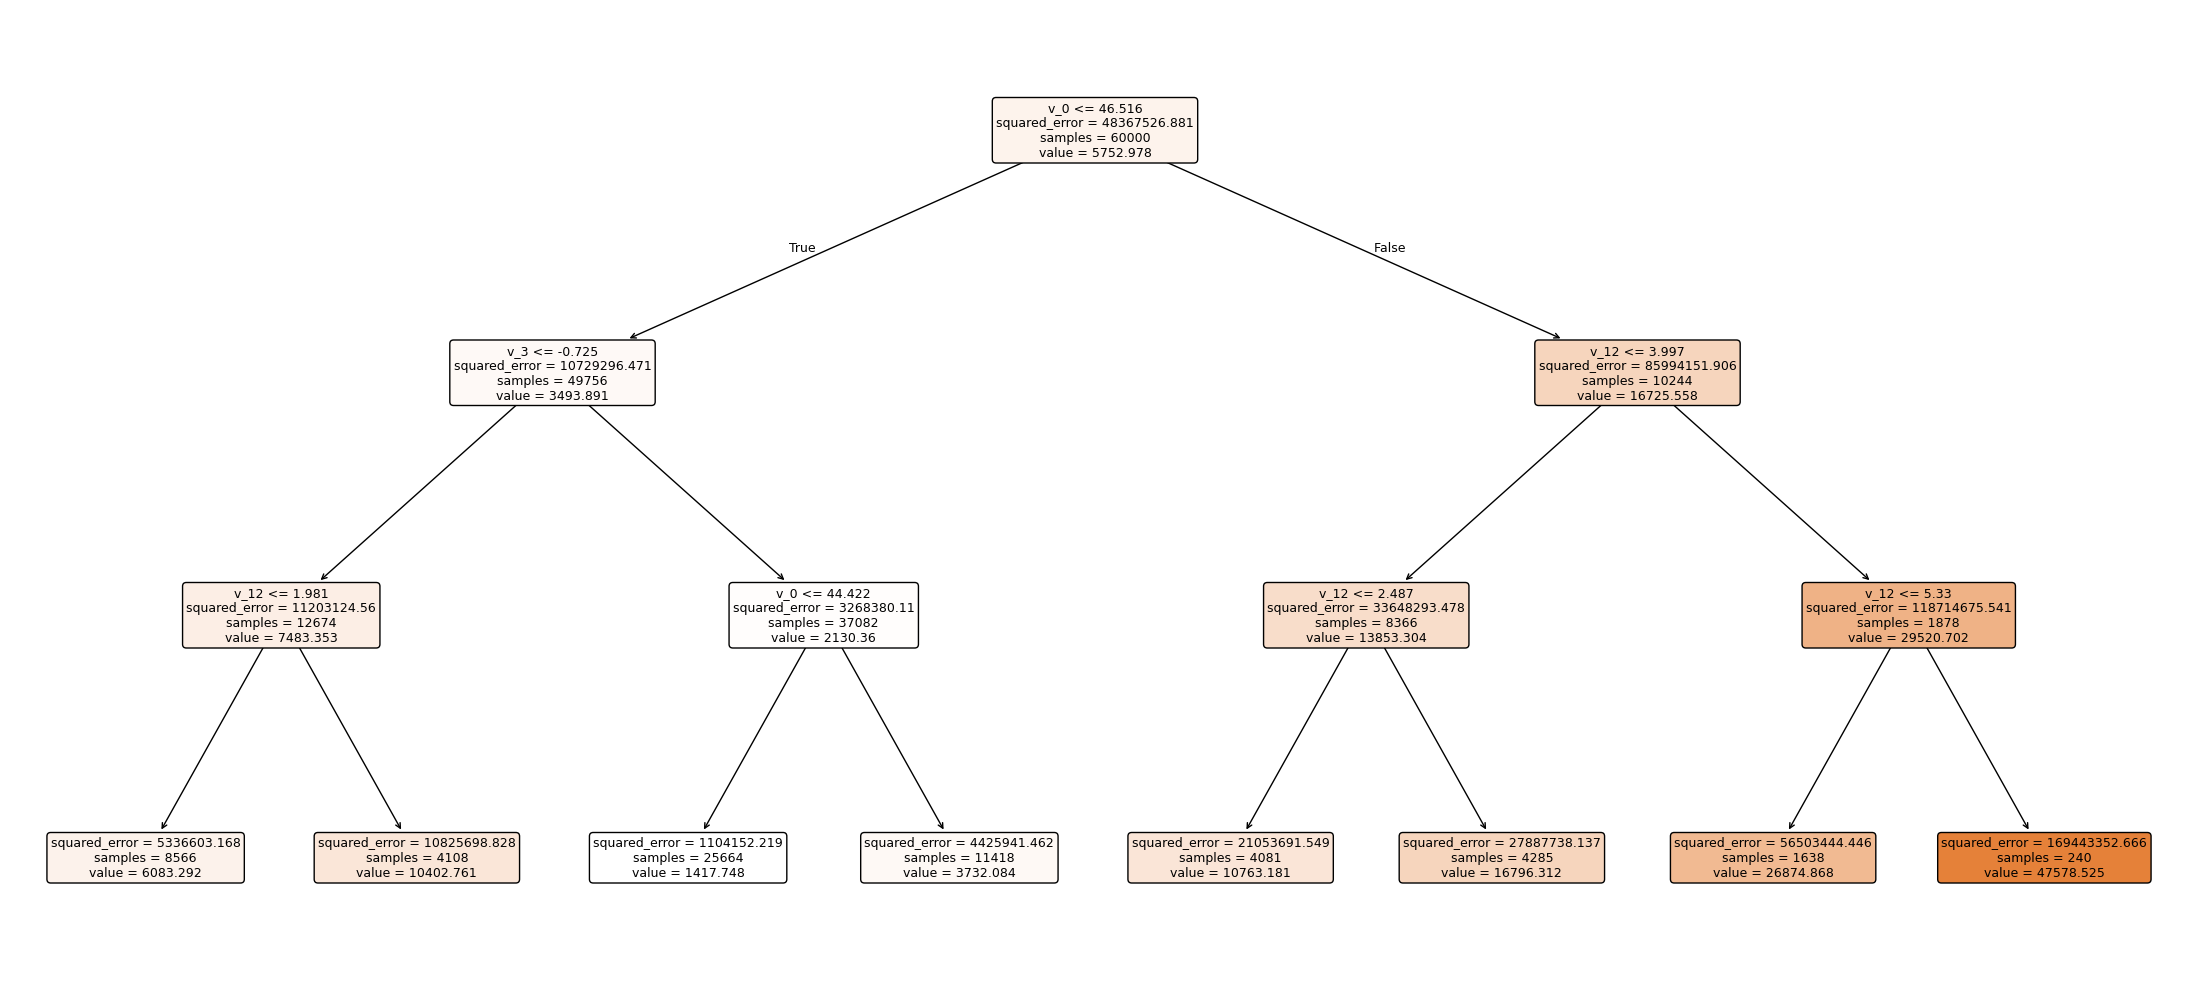

In [60]:
draw_tree(model_dt, feature_names = X_small.columns.tolist(), precision = 3)

In [61]:
model_rf = RandomForestRegressor(
    # parameters shared with DecisionTreeRegressor
    n_estimators = 1, # = the model is a single tree
    criterion = 'squared_error', 
    max_depth = 3,
    min_samples_split = 2, 
    min_samples_leaf = 1,
    min_weight_fraction_leaf = 0.0, 
    max_features = None, 
    max_leaf_nodes = None, 
    min_impurity_decrease = 0.0,
    ccp_alpha = 0.0, 
    random_state = 42,
    
    # RandomForestRegressor specific hyperparameters
    bootstrap = False, # default = True 
    oob_score = False, 
    max_samples = None,

    # extra parameters
    warm_start = False, 
    n_jobs = -1,
    verbose = 0, 
)

In [62]:
%time model_rf.fit(X_small, y_small)
print_score(model_rf, X_small, y_small, X_valid, y_valid)

CPU times: total: 297 ms
Wall time: 314 ms
RMSE on train set: 2908.8824
RMSE on valid set: 3036.8245
R^2 on train set: 0.8251
R^2 on valid set: 0.8096


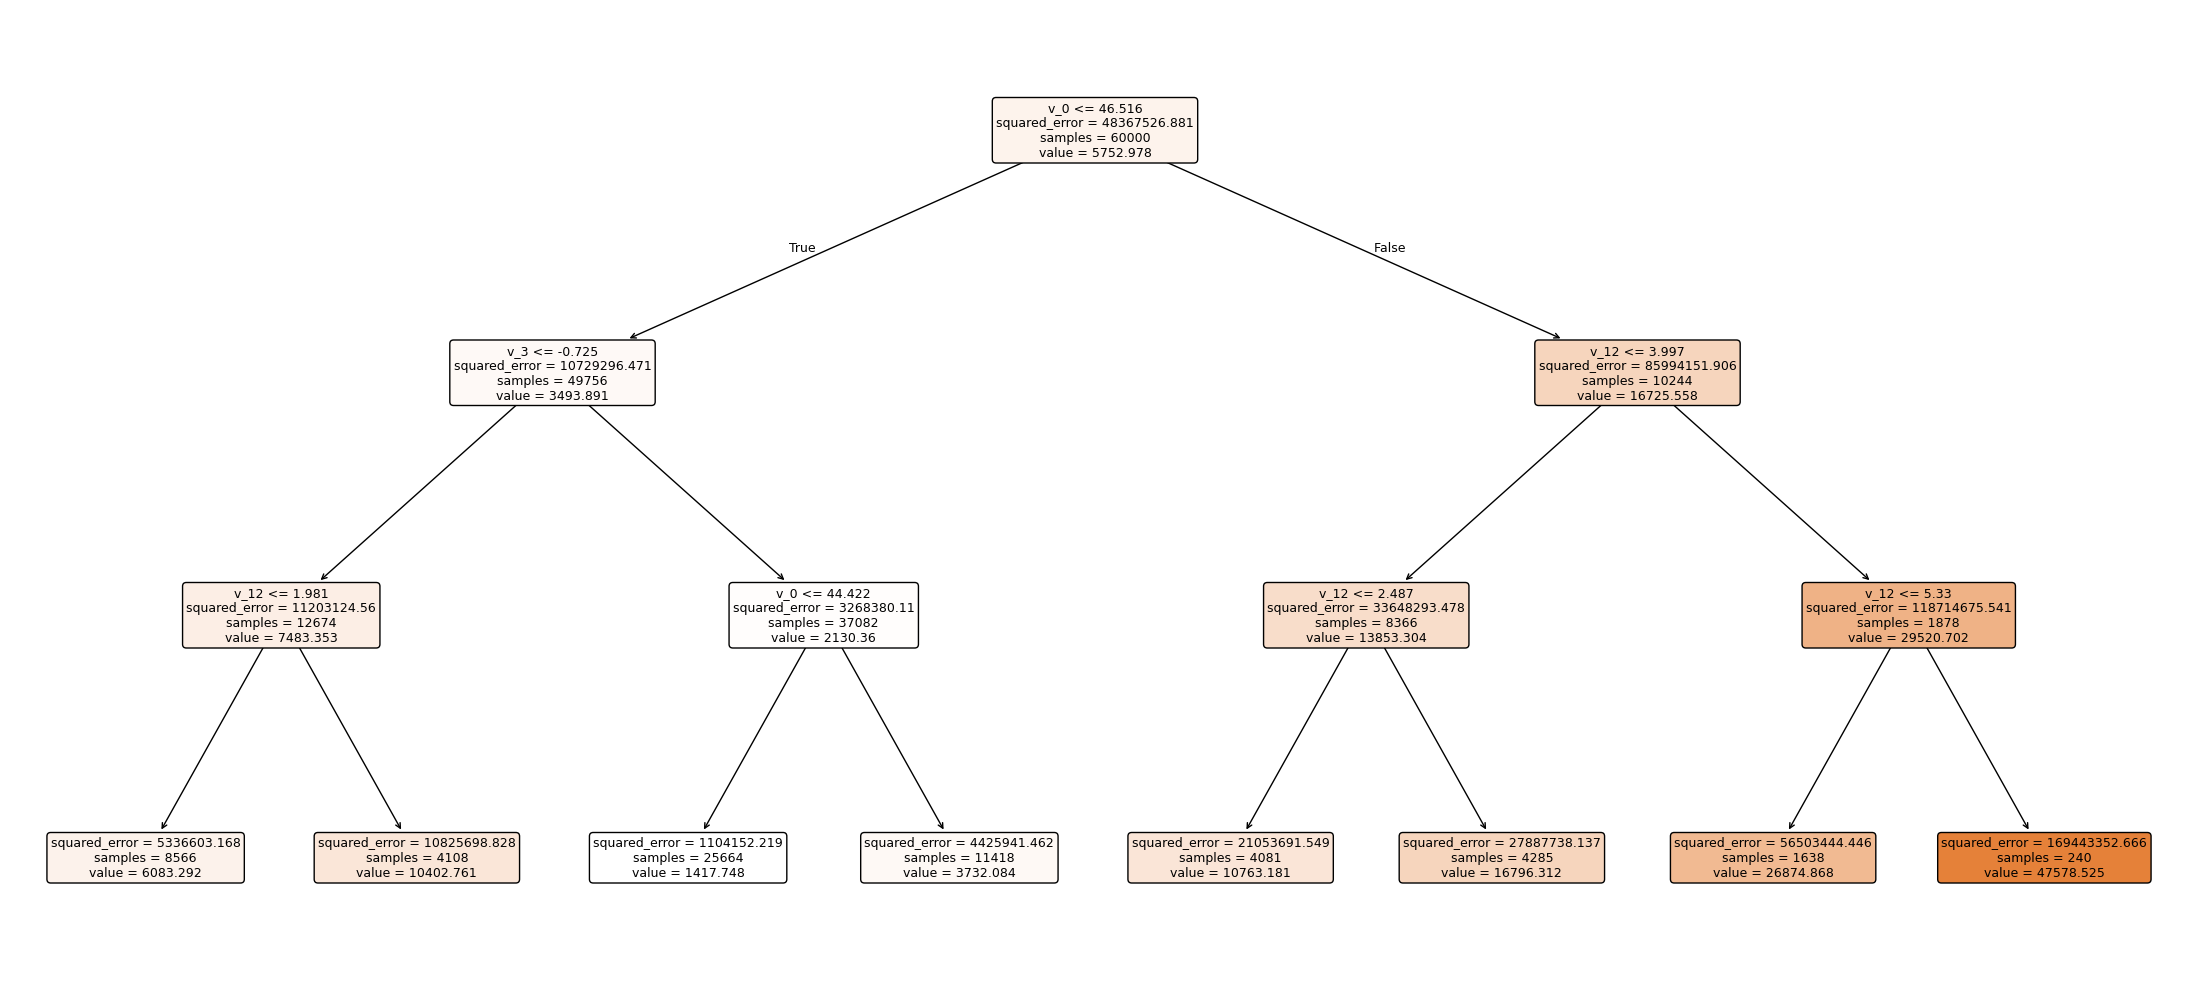

In [63]:
draw_tree(model_rf.estimators_[0], X_small.columns.tolist(), precision = 3)

In [64]:
model_rf = RandomForestRegressor(
    # parameters shared with DecisionTreeRegressor
    n_estimators = 2, # 1 = the model is a single tree
    criterion = 'squared_error', 
    max_depth = 3,
    min_samples_split = 2, 
    min_samples_leaf = 1,
    min_weight_fraction_leaf = 0.0, 
    max_features = 0.5, 
    max_leaf_nodes = None, 
    min_impurity_decrease = 0.0,
    ccp_alpha = 0.0, 
    random_state = 42,
    
    # RandomForestRegressor specific hyperparameters
    bootstrap = True, # default = True 
    oob_score = False, 
    max_samples = 0.5,

    # extra parameters
    warm_start = False, 
    n_jobs = -1, # None 
    verbose = 0, 
)

In [65]:
%time model_rf.fit(X_small, y_small)
print_score(model_rf, X_small, y_small, X_valid, y_valid)

CPU times: total: 156 ms
Wall time: 118 ms
RMSE on train set: 3013.5028
RMSE on valid set: 3058.1004
R^2 on train set: 0.8122
R^2 on valid set: 0.8070


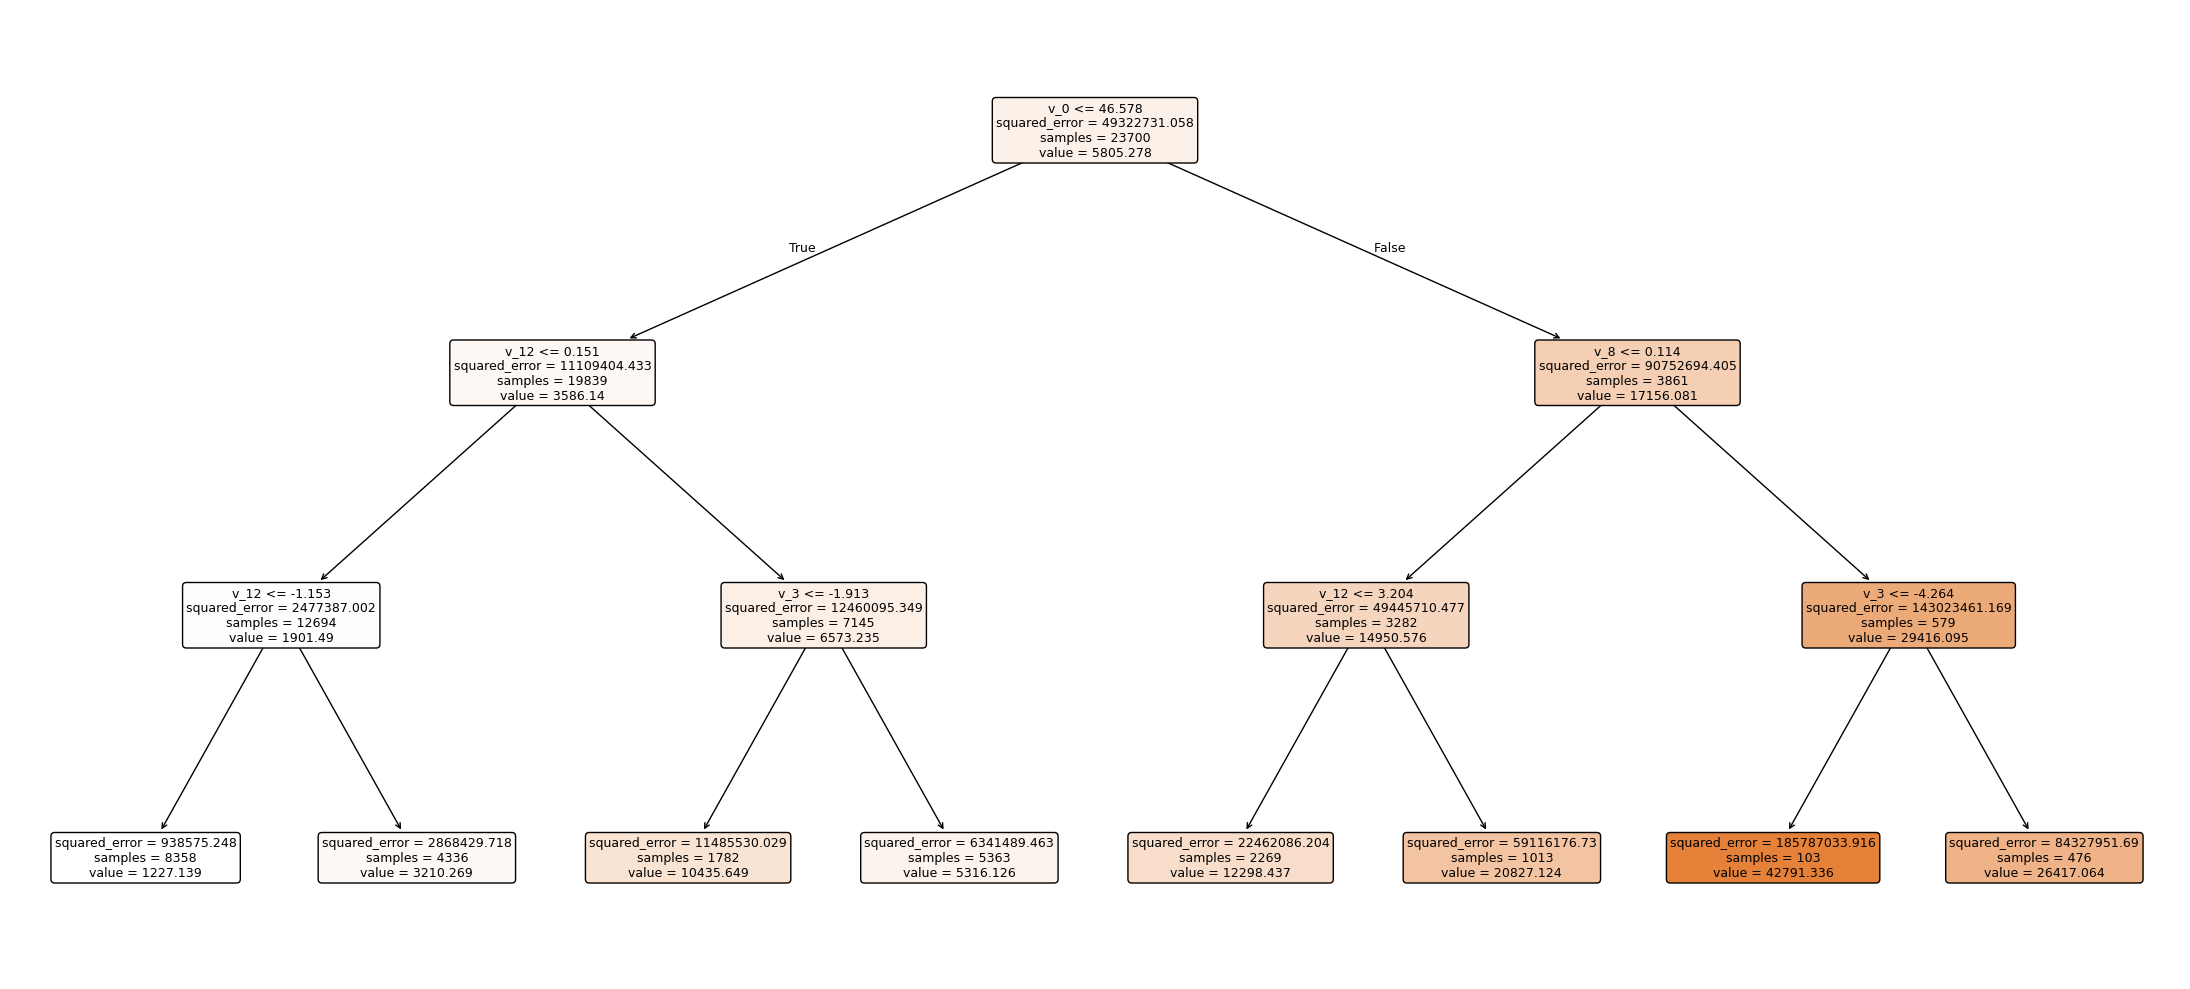

In [66]:
draw_tree(model_rf.estimators_[0], X_small.columns.tolist(), precision = 3)

In [67]:
model_dt = DecisionTreeRegressor(
    criterion = 'squared_error', # 'mse', 
    splitter = 'best', 
    max_depth = 10,
    min_samples_split = 2, 
    min_samples_leaf = 1,
    min_weight_fraction_leaf = 0.0, 
    max_features = None, 
    max_leaf_nodes = None, 
    min_impurity_decrease = 0.0,
    random_state = 42,
    ccp_alpha = 0.0, 
)

In [68]:
model_dt.fit(X_small, y_small)
print_score(model_dt, X_small, y_small, X_valid, y_valid)

RMSE on train set: 1313.7113
RMSE on valid set: 1971.1566
R^2 on train set: 0.9643
R^2 on valid set: 0.9198


In [69]:
model_dt = DecisionTreeRegressor(
    criterion = 'squared_error', # 'mse', 
    splitter = 'best', 
    max_depth = None,
    min_samples_split = 2, 
    min_samples_leaf = 1,
    min_weight_fraction_leaf = 0.0, 
    max_features = None, 
    max_leaf_nodes = None, 
    min_impurity_decrease = 0.0,
    random_state = 42,
    ccp_alpha = 0.0, 
)

In [70]:
model_dt.fit(X_small, y_small)
print_score(model_dt, X_small, y_small, X_valid, y_valid)

RMSE on train set: 0.0000
RMSE on valid set: 2143.0862
R^2 on train set: 1.0000
R^2 on valid set: 0.9052


In [71]:
base_model = RandomForestRegressor(
    # parameters shared with DecisionTreeRegressor
    n_estimators = 10, # 100 # 1 = the model is a single tree
    criterion = 'squared_error', 
    max_depth = 10,
    min_samples_split = 2, 
    min_samples_leaf = 1,
    min_weight_fraction_leaf = 0.0, 
    max_features = None, 
    max_leaf_nodes = None, 
    min_impurity_decrease = 0.0,
    ccp_alpha = 0.0, 
    random_state = 42,
    
    # RandomForestRegressor specific hyperparameters
    bootstrap = True,
    oob_score = False, 
    max_samples = None,

    # extra parameters
    warm_start = False, 
    n_jobs = -1,
    verbose = 0, 
)

%time base_model.fit(X_small, y_small)
print_score(base_model, X_small, y_small, X_valid, y_valid)

CPU times: total: 7.72 s
Wall time: 1.07 s
RMSE on train set: 1195.8719
RMSE on valid set: 1575.3251
R^2 on train set: 0.9704
R^2 on valid set: 0.9488


In [72]:
point = X_valid.iloc[0,:]
print(point)

price = y_valid[0]
print(price, np.exp(price))

SaleID                     137929
name                         6990
model                         5.0
brand                           5
bodyType                      4.0
fuelType                      0.0
gearbox                       0.0
power                         136
kilometer                    12.5
notRepairedDamage               2
seller                          0
offerType                       0
v_0                      44.09375
v_1                      4.066406
v_2                     -1.647461
v_3                      0.371338
v_4                      0.244507
v_5                      0.265869
v_6                      0.101074
v_7                           0.0
v_8                      0.038971
v_9                      0.070435
v_10                    -3.865234
v_11                     0.745605
v_12                    -1.928711
v_13                     0.599609
v_14                      0.23291
train                         1.0
test                          0.0
used_time     

In [73]:
# the model makes prediction with model.predict method
# base_model.predict

# predict takes a list as input, so we turn our single point as a list (with a single element)
base_model.predict([point])

# the model returns a list, so we take the first element, and apply exponetial
np.exp(base_model.predict([point])[0])

np.float64(inf)

In [74]:
# model prediction on single data point
trees = base_model
point = [X_valid.iloc[0, :]]
pred = trees.predict(point)

print('Type:', type(pred))
print('Shape:', pred.shape)
print('Value:', np.exp(pred[0]))

Type: <class 'numpy.ndarray'>
Shape: (1,)
Value: inf


In [75]:
# first tree prediction on single data point
tree = base_model.estimators_[0] # chose between 0 and 9 since we have 10 estimators
point = [X_valid.iloc[0, :]]     # tree.predict takes an iterable of data points as input
pred = tree.predict(point)       # tree.predict returns a numpy tensor of predictions as output

print('Type:', type(pred))
print('Shape:', pred.shape)
print('Value:', np.exp(pred[0]))

Type: <class 'numpy.ndarray'>
Shape: (1,)
Value: inf


In [76]:
# first tree prediction on single data point
tree = base_model.estimators_[1] # chose between 0 and 9 since we have 10 estimators
point = [X_valid.iloc[0, :]]     # tree.predict takes an iterable of data points as input
pred = tree.predict(point)       # tree.predict returns a numpy tensor of predictions as output

print('Type:', type(pred))
print('Shape:', pred.shape)
print('Value:', np.exp(pred[0]))

Type: <class 'numpy.ndarray'>
Shape: (1,)
Value: inf


In [77]:
# all tree predictions on single data point
trees = base_model.estimators_
point = [X_valid.iloc[0, :]]
preds = np.asarray([tree.predict(point) for tree in trees])

print('Type:', type(preds))
print('Shape:', preds.shape)
print('Value:', np.exp(preds))

Type: <class 'numpy.ndarray'>
Shape: (10, 1)
Value: [[inf]
 [inf]
 [inf]
 [inf]
 [inf]
 [inf]
 [inf]
 [inf]
 [inf]
 [inf]]


In [78]:
# all tree predictions on all data
preds = np.stack([tree.predict(X_valid) for tree in base_model.estimators_]) # or np.asarray()

# predictions of the 10 trees, mean, and actual value (for first point in validation set)
preds[:,0], base_model.predict(point)[0], np.mean(preds[:,0]), y_valid[0]

(array([2642.39285714, 2640.93367347, 2019.77927928, 3311.34108527,
        2878.1212766 , 2378.22322775, 3427.96989967, 2792.31203931,
        2272.80519481, 2404.76557864]),
 np.float64(2676.8644111929034),
 np.float64(2676.8644111929025),
 np.float64(2299.0))

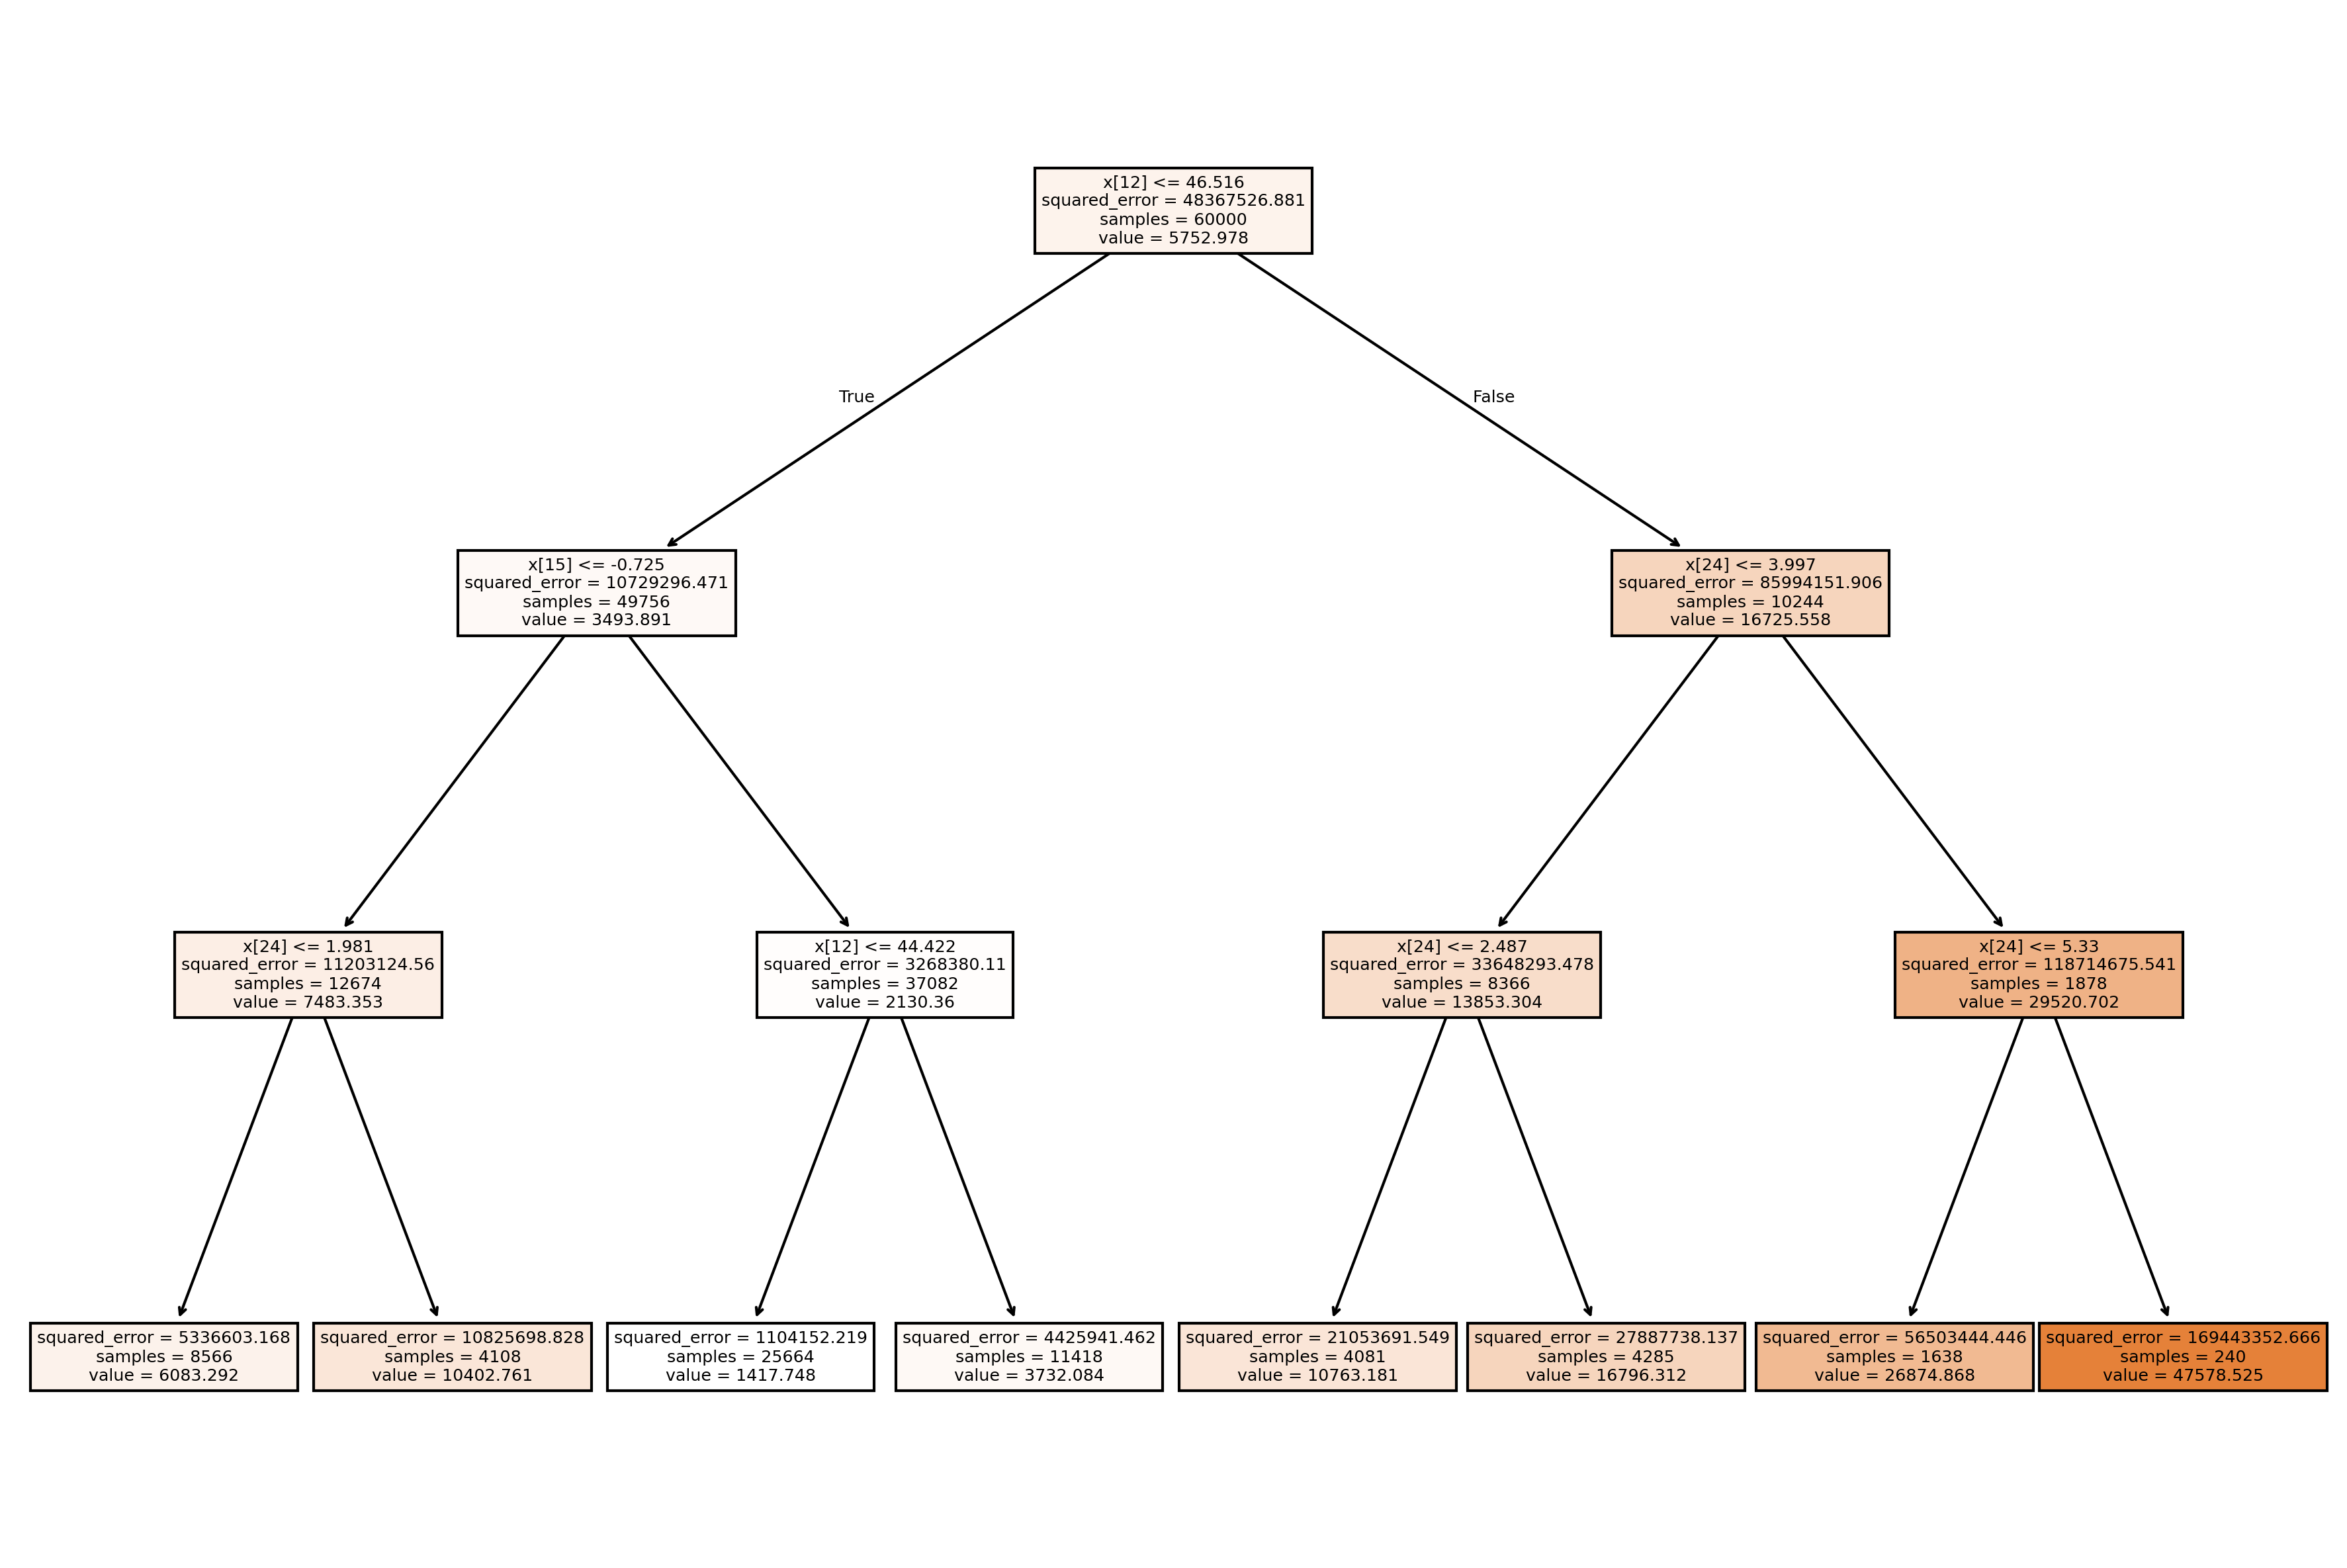

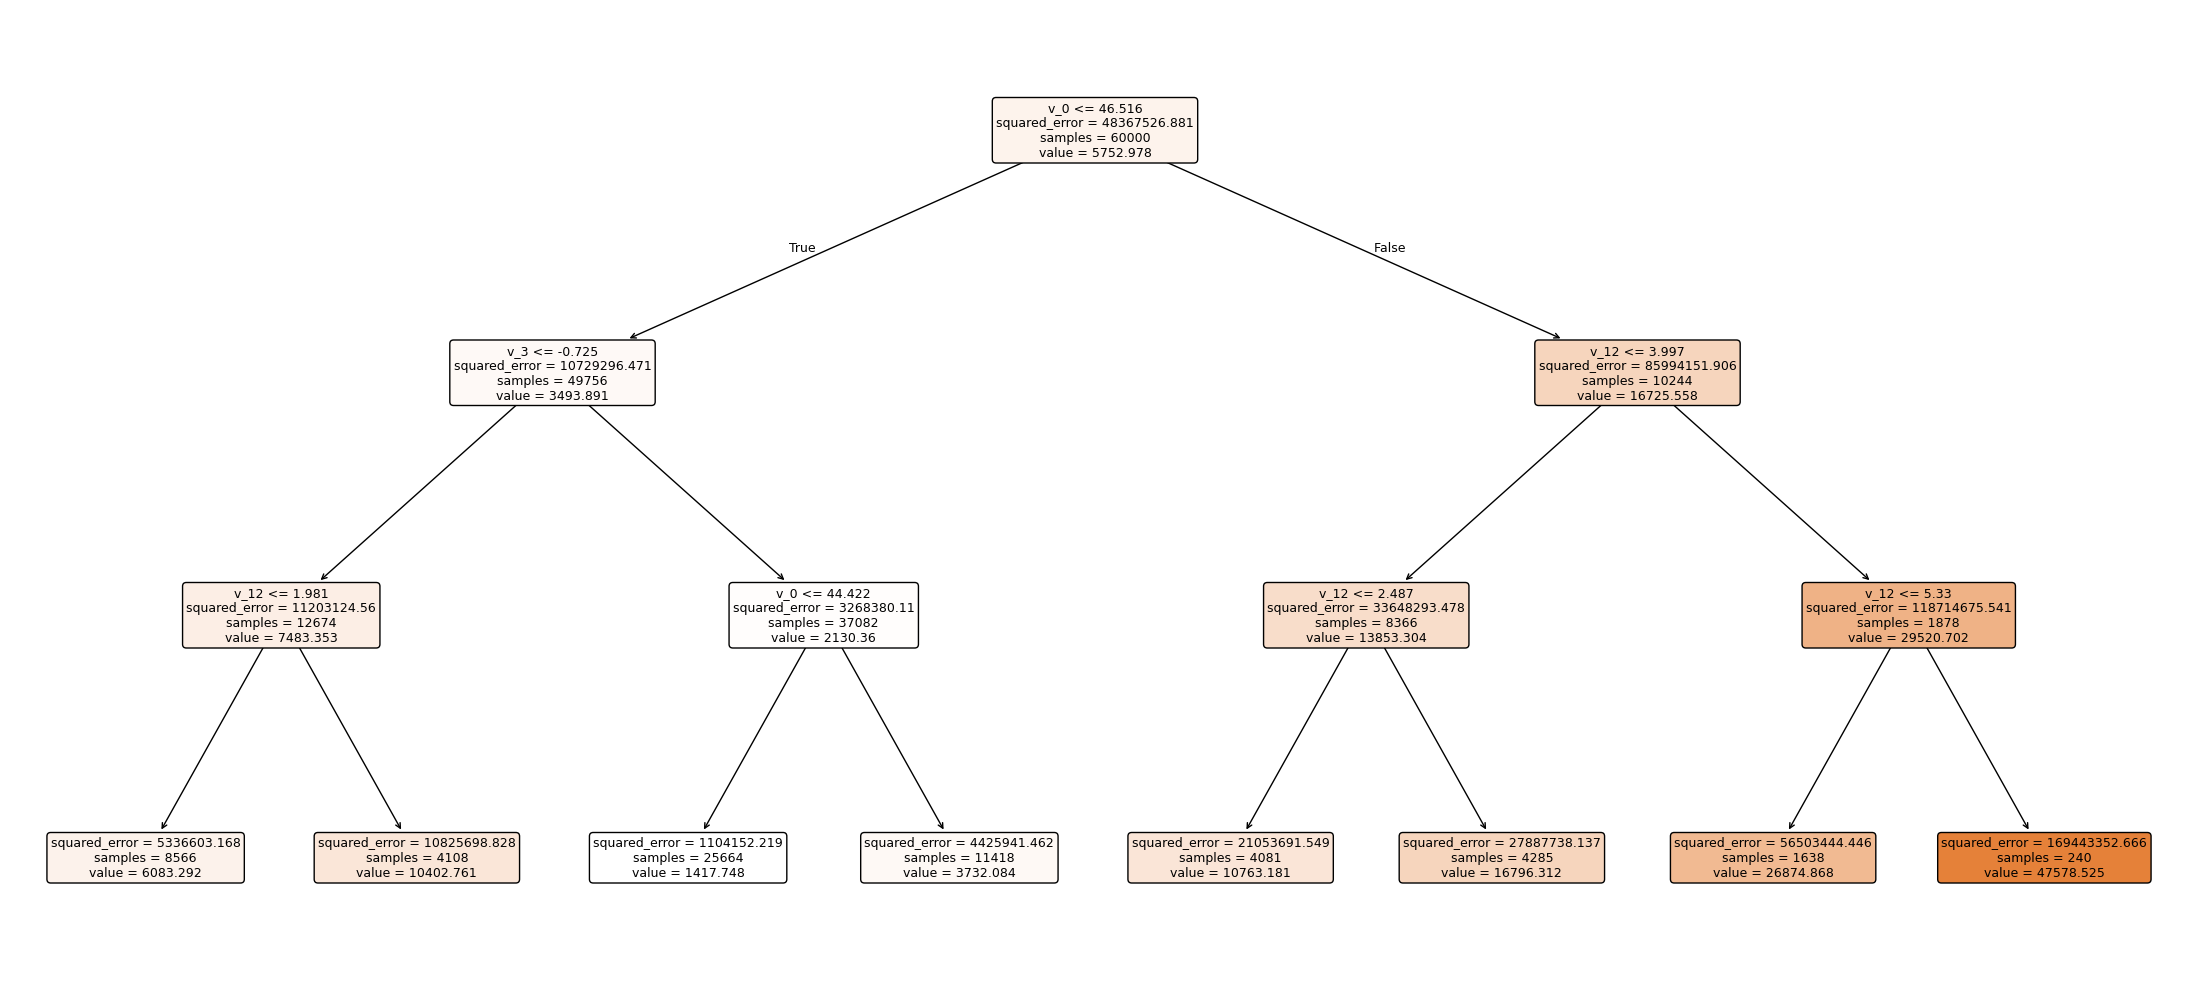

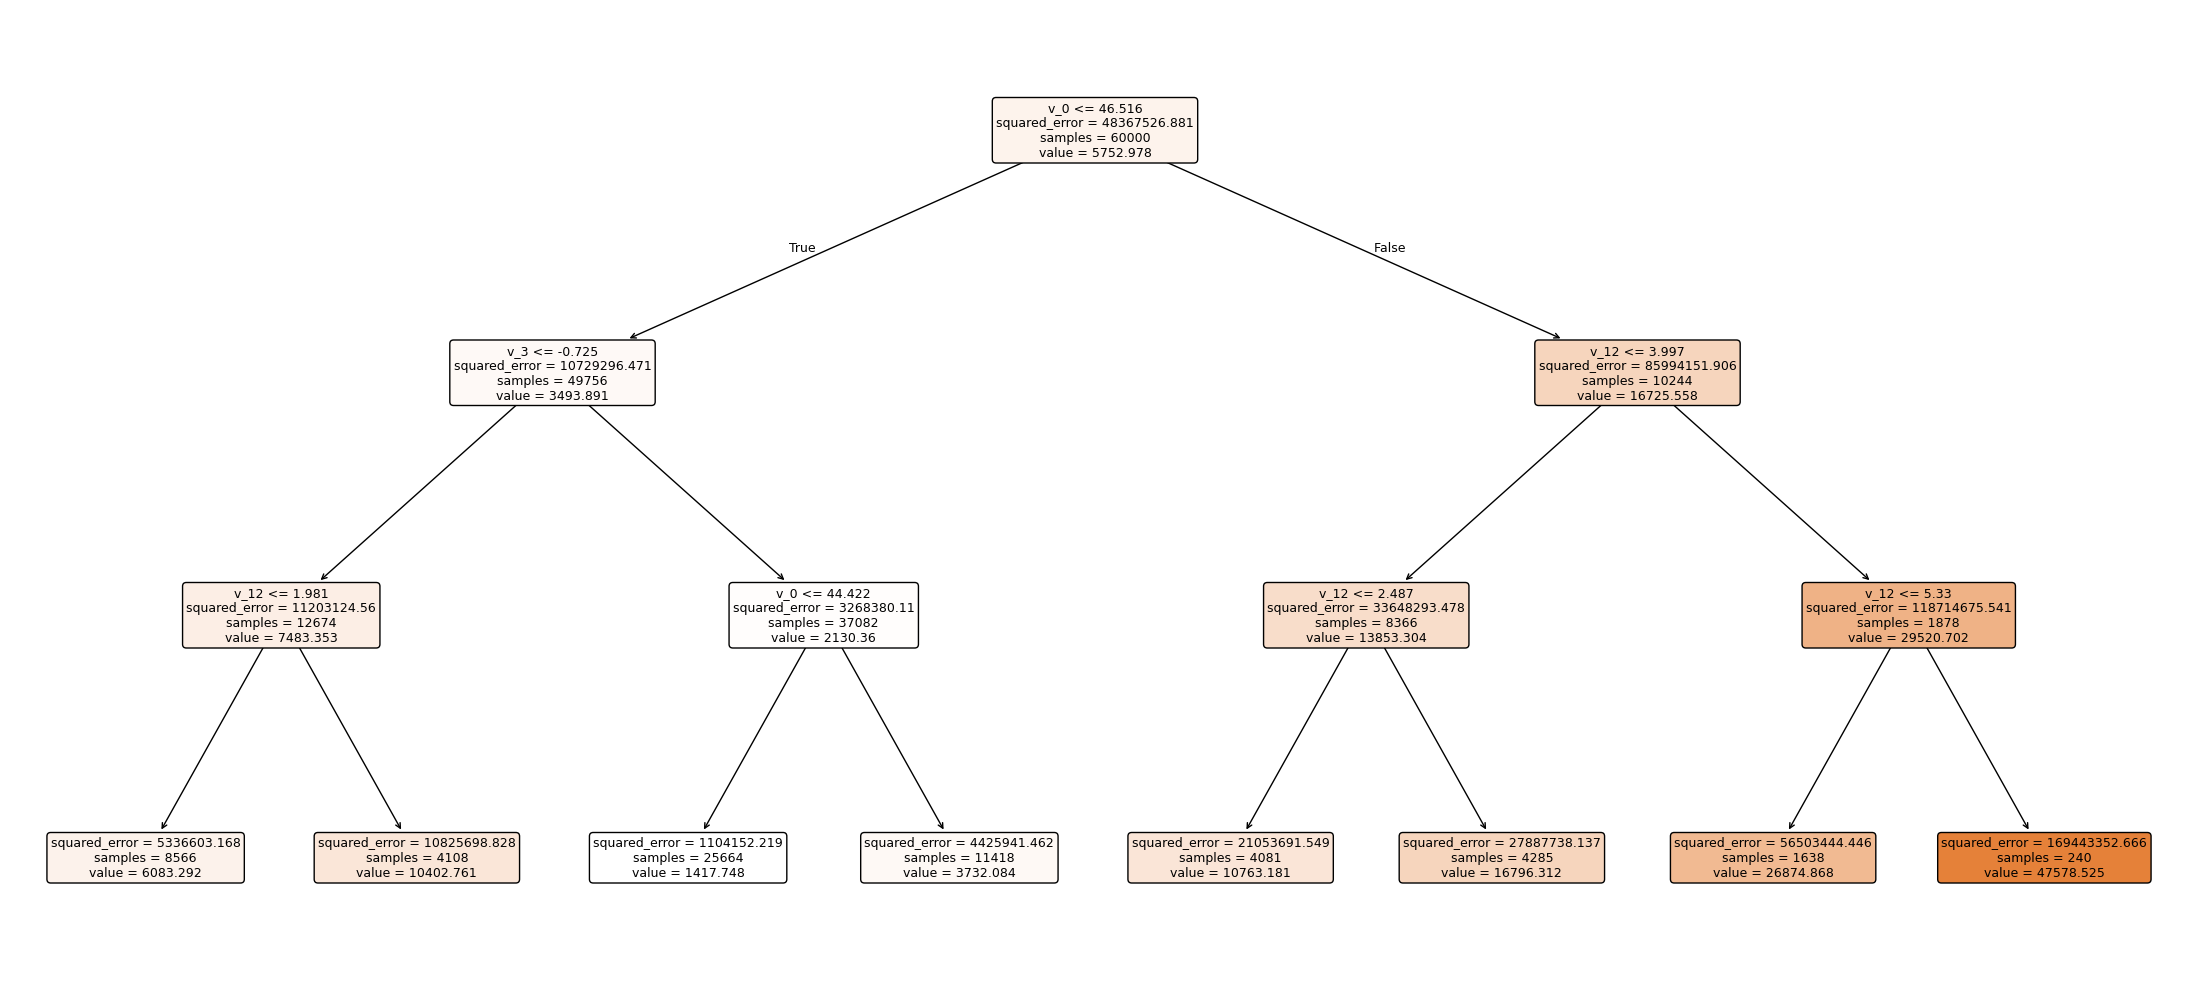

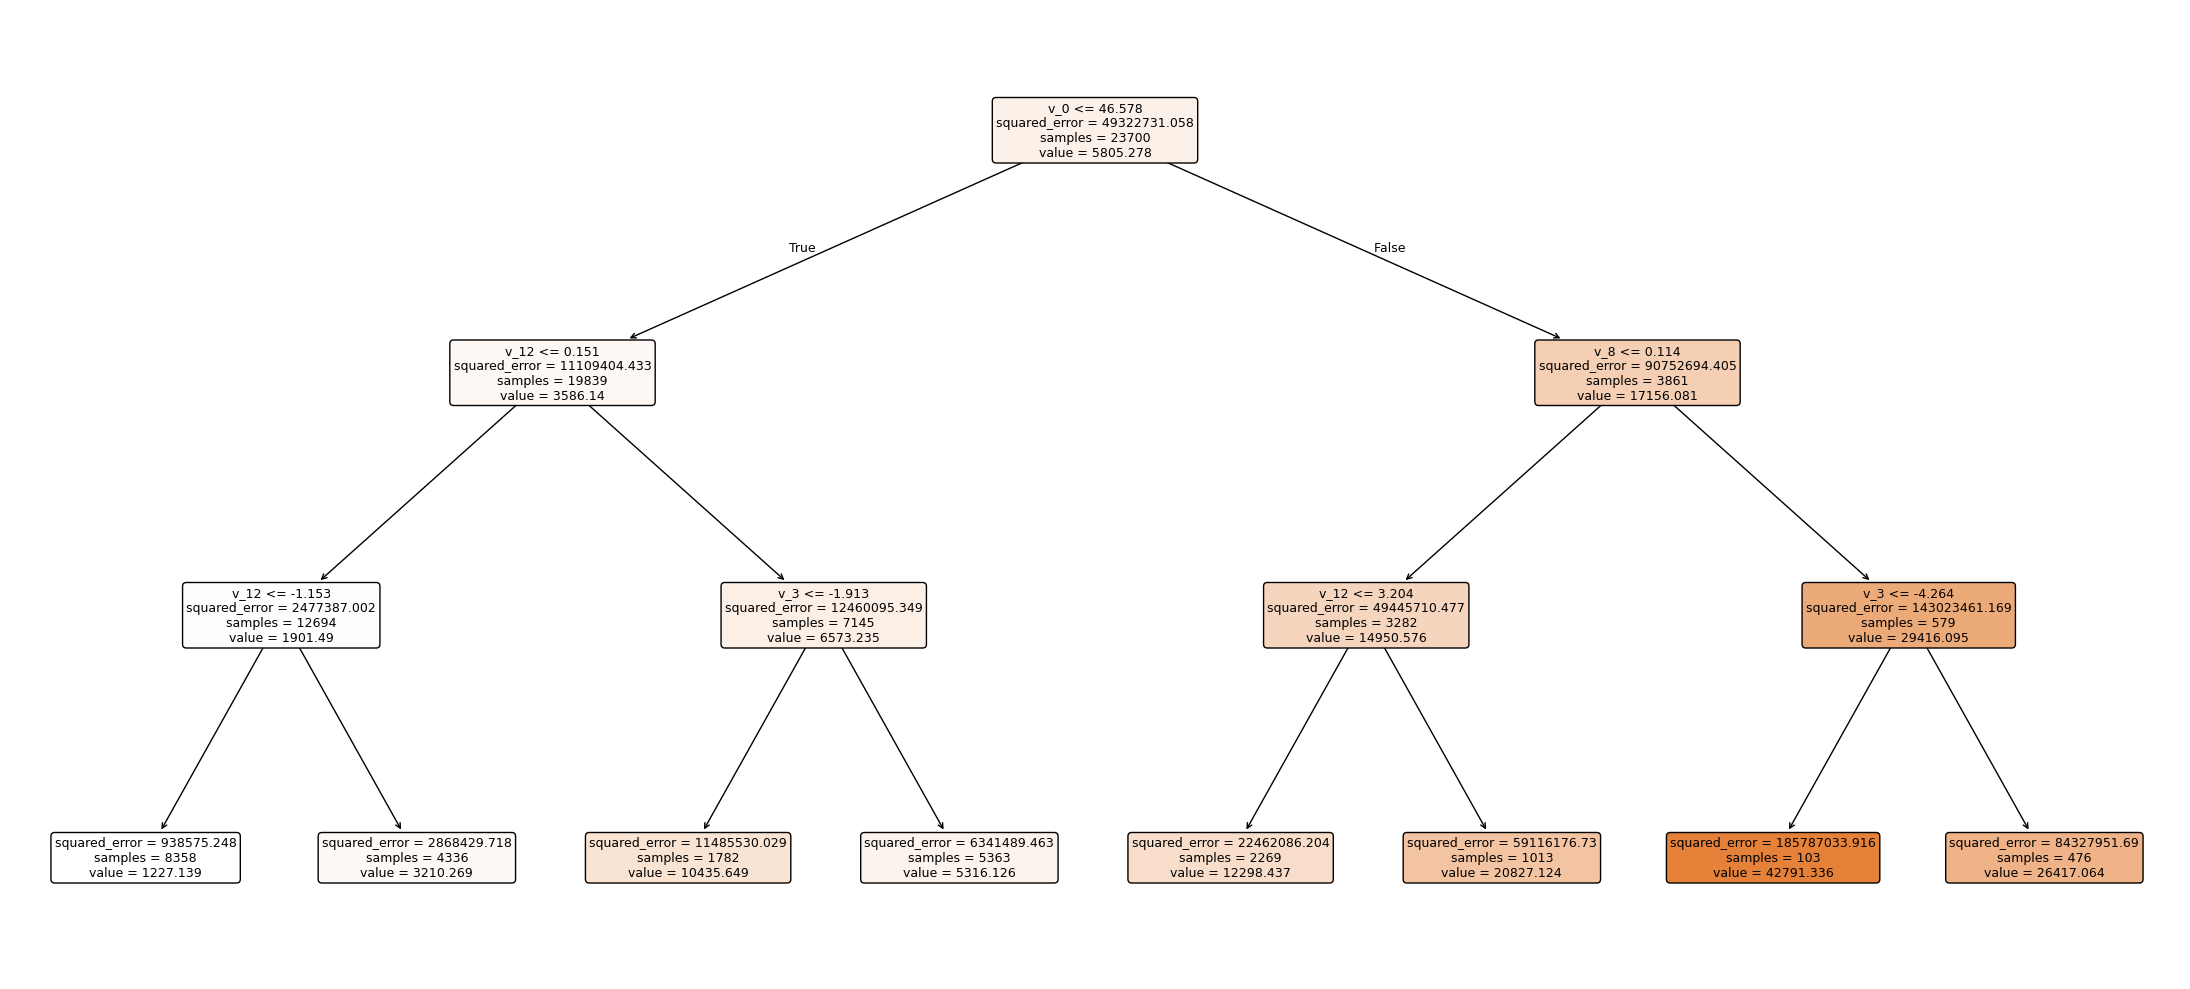

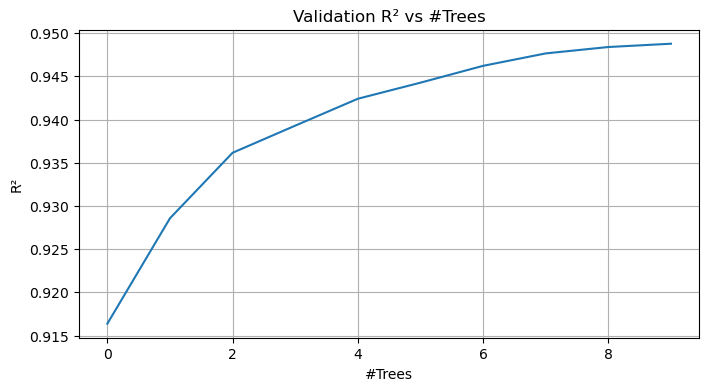

In [79]:
plt.figure(figsize=(8,4))
plt.plot([
    metrics.r2_score(y_valid, np.mean(preds[:num_trees], axis=0))
    for num_trees in range(1, 11)
])
plt.title("Validation R² vs #Trees")
plt.xlabel("#Trees")
plt.ylabel("R²")
plt.grid(True)
plt.show()
plt.close()

In [80]:
model = RandomForestRegressor(
    # parameters shared with DecisionTreeRegressor
    n_estimators = 20, # 100 # 1 = the model is a single tree
    criterion = 'squared_error', 
    max_depth = 10,
    min_samples_split = 2, 
    min_samples_leaf = 1,
    min_weight_fraction_leaf = 0.0, 
    max_features = None, 
    max_leaf_nodes = None, 
    min_impurity_decrease = 0.0,
    ccp_alpha = 0.0, 
    random_state = 42,
    
    # RandomForestRegressor specific hyperparameters
    bootstrap = True,
    oob_score = False, 
    max_samples = None,

    # extra parameters
    warm_start = False, 
    n_jobs = -1,
    verbose = 0, 
)

%time model.fit(X_small, y_small)
print_score(model, X_small, y_small, X_valid, y_valid)

CPU times: total: 14.4 s
Wall time: 1.82 s
RMSE on train set: 1165.0684
RMSE on valid set: 1543.0352
R^2 on train set: 0.9719
R^2 on valid set: 0.9509


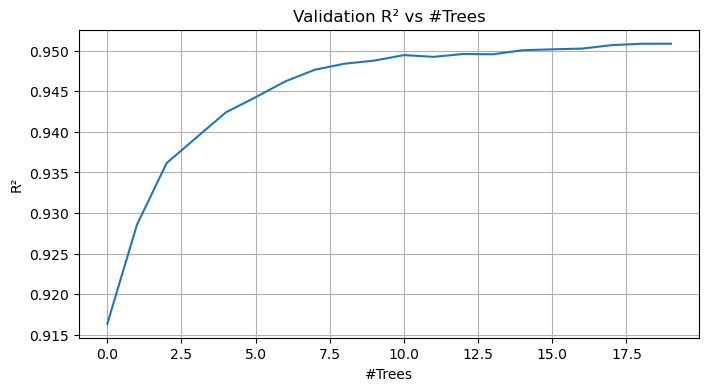

In [81]:
# all tree predictions on all data
preds = np.stack([tree.predict(X_valid) for tree in model.estimators_]) # or np.asarray()

# predictions of the 10 trees, mean, and actual value (for first point in validation set)
preds.shape, preds[:,0], np.mean(preds[:,0]), y_valid[0]

plt.figure(figsize=(8,4))
plt.plot([
    metrics.r2_score(y_valid, np.mean(preds[:num_trees], axis=0))
    for num_trees in range(1, 21)
])
plt.title("Validation R² vs #Trees")
plt.xlabel("#Trees")
plt.ylabel("R²")
plt.grid(True)
plt.show()
plt.close()

In [82]:
model = RandomForestRegressor(
    # parameters shared with DecisionTreeRegressor
    n_estimators = 30, # 100 # 1 = the model is a single tree
    criterion = 'squared_error', 
    max_depth = 10,
    min_samples_split = 2, 
    min_samples_leaf = 1,
    min_weight_fraction_leaf = 0.0, 
    max_features = None, 
    max_leaf_nodes = None, 
    min_impurity_decrease = 0.0,
    ccp_alpha = 0.0, 
    random_state = 42,
    
    # RandomForestRegressor specific hyperparameters
    bootstrap = True,
    oob_score = False, 
    max_samples = None,

    # extra parameters
    warm_start = False, 
    n_jobs = -1,
    verbose = 0, 
)

%time model.fit(X_small, y_small)
print_score(model, X_small, y_small, X_valid, y_valid)

CPU times: total: 24 s
Wall time: 2.43 s
RMSE on train set: 1160.5873
RMSE on valid set: 1540.0115
R^2 on train set: 0.9722
R^2 on valid set: 0.9510


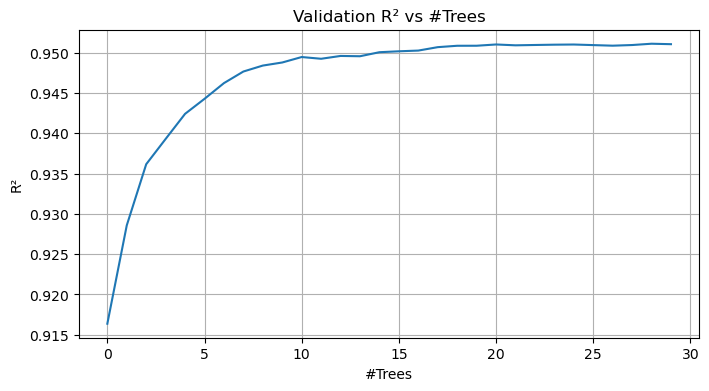

In [83]:
preds = np.stack([tree.predict(X_valid) for tree in model.estimators_]) # or np.asarray()

# predictions of the 10 trees, mean, and actual value (for first point in validation set)
preds.shape, preds[:,0], np.mean(preds[:,0]), y_valid[0]

plt.figure(figsize=(8,4))
plt.plot([
    metrics.r2_score(y_valid, np.mean(preds[:num_trees], axis=0))
    for num_trees in range(1, 31)
])
plt.title("Validation R² vs #Trees")
plt.xlabel("#Trees")
plt.ylabel("R²")
plt.grid(True)
plt.show()
plt.close()

In [84]:
model = RandomForestRegressor(
    # parameters shared with DecisionTreeRegressor
    n_estimators = 50, # 100 # 1 = the model is a single tree
    criterion = 'squared_error', 
    max_depth = 10,
    min_samples_split = 2, 
    min_samples_leaf = 1,
    min_weight_fraction_leaf = 0.0, 
    max_features = None, 
    max_leaf_nodes = None, 
    min_impurity_decrease = 0.0,
    ccp_alpha = 0.0, 
    random_state = 42, 
    
    # RandomForestRegressor specific hyperparameters
    bootstrap = True,
    oob_score = False, 
    max_samples = None,

    # extra parameters
    warm_start = False, 
    n_jobs = -1,
    verbose = 0, 
)

%time model.fit(X_small, y_small)
print_score(model, X_small, y_small, X_valid, y_valid)

CPU times: total: 39.9 s
Wall time: 4.69 s
RMSE on train set: 1153.0637
RMSE on valid set: 1534.2080
R^2 on train set: 0.9725
R^2 on valid set: 0.9514


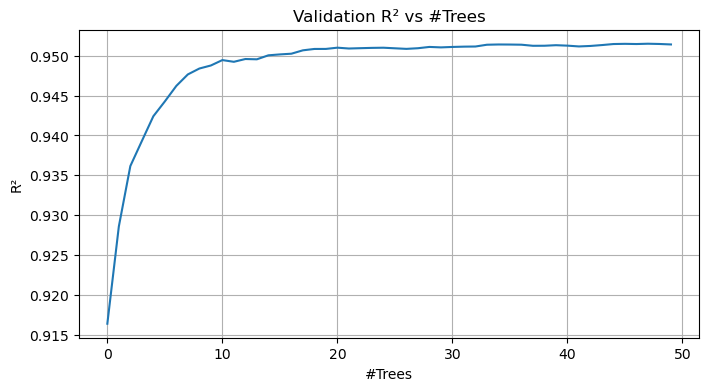

In [85]:
preds = np.stack([tree.predict(X_valid) for tree in model.estimators_]) # or np.asarray()

# predictions of the 10 trees, mean, and actual value (for first point in validation set)
preds.shape, preds[:,0], np.mean(preds[:,0]), y_valid[0]
plt.figure(figsize=(8,4))
plt.plot([
    metrics.r2_score(y_valid, np.mean(preds[:num_trees], axis = 0)) 
    for num_trees in range(1, 51)
])
plt.title("Validation R² vs #Trees")
plt.xlabel("#Trees")
plt.ylabel("R²")
plt.grid(True)
plt.show()
plt.close() 

In [86]:
model = RandomForestRegressor(
    # parameters shared with DecisionTreeRegressor
    n_estimators = 50, # 100 # 1 = the model is a single tree
    criterion = 'squared_error', 
    max_depth = 10,
    min_samples_split = 2, 
    min_samples_leaf = 1,
    min_weight_fraction_leaf = 0.0, 
    max_features = None, 
    max_leaf_nodes = None, 
    min_impurity_decrease = 0.0,
    ccp_alpha = 0.0, 
    random_state = 42,
    
    # RandomForestRegressor specific hyperparameters
    bootstrap = True,
    oob_score = False, 
    max_samples = None,

    # extra parameters
    warm_start = False, 
    n_jobs = -1, 
    verbose = 0, 
)

%time model.fit(X_train, y_train)
print_score(model, X_train, y_train, X_valid, y_valid)

CPU times: total: 1min 26s
Wall time: 9.6 s
RMSE on train set: 1261.7424
RMSE on valid set: 1547.9326
R^2 on train set: 0.9675
R^2 on valid set: 0.9505


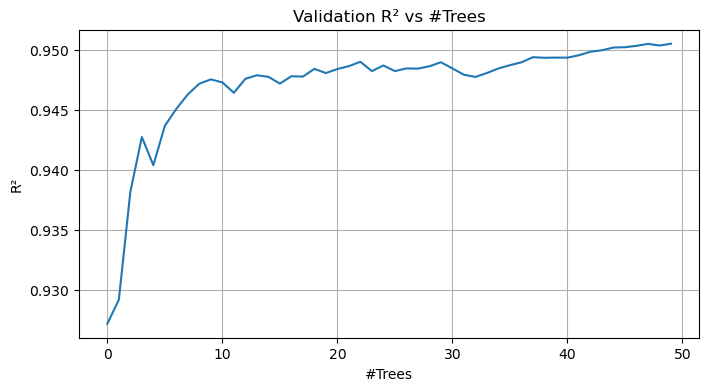

In [87]:
# all tree predictions on all data
preds = np.stack([tree.predict(X_valid) for tree in model.estimators_]) # or np.asarray()

# predictions of the 10 trees, mean, and actual value (for first point in validation set)
preds.shape, preds[:,0], np.mean(preds[:,0]), y_valid[0]
plt.figure(figsize=(8,4))
plt.plot([
    metrics.r2_score(y_valid, np.mean(preds[:num_trees], axis = 0)) 
    for num_trees in range(1, 51)
])
plt.title("Validation R² vs #Trees")
plt.xlabel("#Trees")
plt.ylabel("R²")
plt.grid(True)
plt.show()
plt.close() 

In [88]:
model = RandomForestRegressor(
    n_estimators = 40, 
    n_jobs = -1, 
    random_state = 42,
    
    bootstrap = True,
    oob_score = True, # default = False, 
    max_samples = None,
)

%time model.fit(X_small, y_small)
print_score(model, X_small, y_small, X_valid, y_valid)

CPU times: total: 59.5 s
Wall time: 8.48 s
RMSE on train set: 545.1058
RMSE on valid set: 1433.2618
R^2 on train set: 0.9939
R^2 on valid set: 0.9576
R^2 on oob set: 0.9552


In [89]:
model = RandomForestRegressor(
    n_estimators = 40, 
    n_jobs = -1, 
    random_state = 42,
    
    bootstrap = True,
    oob_score = True, # default = False, 
    max_samples = None,
)

%time model.fit(X_train, y_train)
print_score(model, X_train, y_train, X_valid, y_valid)

CPU times: total: 2min 31s
Wall time: 18.8 s
RMSE on train set: 523.3626
RMSE on valid set: 1413.3703
R^2 on train set: 0.9944
R^2 on valid set: 0.9588
R^2 on oob set: 0.9599


In [90]:
def decision_tree_max_depth(tree):
    children_left = tree.children_left
    children_right = tree.children_right

    def walk(node_id):
        if (children_left[node_id] != children_right[node_id]):
            left_max = 1 + walk(children_left[node_id])
            right_max = 1 + walk(children_right[node_id])
            return max(left_max, right_max)
        else: # leaf
            return 1

    root_node_id = 0
    return walk(root_node_id)

In [91]:
model = RandomForestRegressor(
    n_estimators = 40, 
    criterion = 'squared_error', 
    
    # stoping criteria
    max_depth = None,
    min_samples_split = 2, 
    min_samples_leaf = 1,
    min_weight_fraction_leaf = 0.0, 
    max_leaf_nodes = None, 
    min_impurity_decrease = 0.0, 
    ccp_alpha = 0.0, 
 
    # bagging parameters
    max_features = None, 
    bootstrap = True,
    oob_score = True, 
    max_samples = None,
    
    # other
    warm_start = False, 
    n_jobs = -1,
    random_state = 42,
    verbose = 0, 
)

%time model.fit(X_small, y_small)
print_score(model, X_small, y_small, X_valid, y_valid)

CPU times: total: 1min 4s
Wall time: 8.43 s
RMSE on train set: 545.1058
RMSE on valid set: 1433.2618
R^2 on train set: 0.9939
R^2 on valid set: 0.9576
R^2 on oob set: 0.9552


In [92]:
tree = model.estimators_[0].tree_

decision_tree_max_depth(tree)

42

In [93]:
for i, tree in enumerate(model.estimators_):
    print('tree {} has depth {}'.format(i, decision_tree_max_depth(tree.tree_)))

tree 0 has depth 42
tree 1 has depth 37
tree 2 has depth 44
tree 3 has depth 40
tree 4 has depth 46
tree 5 has depth 42
tree 6 has depth 45
tree 7 has depth 41
tree 8 has depth 42
tree 9 has depth 39
tree 10 has depth 36
tree 11 has depth 40
tree 12 has depth 40
tree 13 has depth 42
tree 14 has depth 36
tree 15 has depth 42
tree 16 has depth 44
tree 17 has depth 41
tree 18 has depth 40
tree 19 has depth 42
tree 20 has depth 41
tree 21 has depth 43
tree 22 has depth 38
tree 23 has depth 39
tree 24 has depth 42
tree 25 has depth 42
tree 26 has depth 40
tree 27 has depth 38
tree 28 has depth 39
tree 29 has depth 48
tree 30 has depth 41
tree 31 has depth 44
tree 32 has depth 43
tree 33 has depth 42
tree 34 has depth 39
tree 35 has depth 44
tree 36 has depth 40
tree 37 has depth 42
tree 38 has depth 43
tree 39 has depth 38


In [94]:
model = RandomForestRegressor(
    n_estimators = 40, 
    min_samples_split = 15,
    min_samples_leaf = 15,
    n_jobs = -1, 
    random_state = 42,
    
    bootstrap = True,
    oob_score = True, # default = False, 
    max_samples = None,
)

%time model.fit(X_small, y_small)
print_score(model, X_small, y_small, X_valid, y_valid)

CPU times: total: 37.5 s
Wall time: 5.18 s
RMSE on train set: 1316.4260
RMSE on valid set: 1608.6015
R^2 on train set: 0.9642
R^2 on valid set: 0.9466
R^2 on oob set: 0.9479


In [95]:
tree = model.estimators_[0].tree_

decision_tree_max_depth(tree)

25

In [96]:
for i, tree in enumerate(model.estimators_):
    print('tree {} has depth {}'.format(i, decision_tree_max_depth(tree.tree_)))

tree 0 has depth 25
tree 1 has depth 23
tree 2 has depth 24
tree 3 has depth 23
tree 4 has depth 25
tree 5 has depth 25
tree 6 has depth 27
tree 7 has depth 25
tree 8 has depth 25
tree 9 has depth 26
tree 10 has depth 23
tree 11 has depth 24
tree 12 has depth 25
tree 13 has depth 23
tree 14 has depth 23
tree 15 has depth 24
tree 16 has depth 23
tree 17 has depth 25
tree 18 has depth 27
tree 19 has depth 25
tree 20 has depth 24
tree 21 has depth 23
tree 22 has depth 23
tree 23 has depth 25
tree 24 has depth 24
tree 25 has depth 23
tree 26 has depth 26
tree 27 has depth 23
tree 28 has depth 23
tree 29 has depth 25
tree 30 has depth 23
tree 31 has depth 23
tree 32 has depth 23
tree 33 has depth 26
tree 34 has depth 23
tree 35 has depth 23
tree 36 has depth 23
tree 37 has depth 24
tree 38 has depth 24
tree 39 has depth 26


In [97]:
model = RandomForestRegressor(
    n_estimators = 40,
    n_jobs = -1, 
    random_state = 42,
    
    bootstrap = True,
    oob_score = True, # default = False
    max_samples = None,
)

%time model.fit(X_train, y_train)
print_score(model, X_train, y_train, X_valid, y_valid)

CPU times: total: 2min 26s
Wall time: 14.1 s
RMSE on train set: 523.3626
RMSE on valid set: 1413.3703
R^2 on train set: 0.9944
R^2 on valid set: 0.9588
R^2 on oob set: 0.9599


In [98]:
model = RandomForestRegressor(
    n_estimators = 40,
    n_jobs = -1, 
    random_state = 42,
    
    bootstrap = True,
    oob_score = True, # default = False
    max_samples = 0.15, # default = None
)

%time model.fit(X_train, y_train)
print_score(model, X_train, y_train, X_valid, y_valid)

CPU times: total: 36.8 s
Wall time: 4.3 s
RMSE on train set: 1288.8977
RMSE on valid set: 1446.4466
R^2 on train set: 0.9661
R^2 on valid set: 0.9568
R^2 on oob set: 0.9544


In [99]:
model = RandomForestRegressor(
    n_estimators = 200,
    n_jobs = -1, 
    random_state = 42,
    
    bootstrap = True,
    oob_score = True, # default = False
    max_samples = 0.15, # default = None
)

%time model.fit(X_train, y_train)
print_score(model, X_train, y_train, X_valid, y_valid)

CPU times: total: 3min 19s
Wall time: 23 s
RMSE on train set: 1271.0205
RMSE on valid set: 1447.4413
R^2 on train set: 0.9671
R^2 on valid set: 0.9568
R^2 on oob set: 0.9556


In [100]:
model = RandomForestRegressor(
    n_estimators = 40, 
    criterion = 'squared_error', 
    
    # stoping criteria
    max_depth = 15,
    min_samples_split = 2, 
    min_samples_leaf = 1,
    min_weight_fraction_leaf = 0.0, 
    max_leaf_nodes = None, 
    min_impurity_decrease = 0.0, 
    ccp_alpha = 0.0, 
 
    # bagging parameters
    max_features = None, 
    bootstrap = True,
    oob_score = True, 
    max_samples = 0.5,
    
    # other
    warm_start = False, 
    n_jobs = -1,
    random_state = 42,
    verbose = 0, 
)

%time model.fit(X_small, y_small)
print_score(model, X_small, y_small, X_valid, y_valid)

CPU times: total: 33.8 s
Wall time: 5.01 s
RMSE on train set: 955.7148
RMSE on valid set: 1475.6217
R^2 on train set: 0.9811
R^2 on valid set: 0.9551
R^2 on oob set: 0.9543


In [101]:
model = RandomForestRegressor(
    n_estimators = 40,
    # max_features = 0.5, # default = None
    n_jobs = -1, 
    random_state = 42,
    
    bootstrap = True,
    oob_score = True, # default = False
    max_samples = None,
)

%time model.fit(X_small, y_small)
print_score(model, X_small, y_small, X_valid, y_valid)

CPU times: total: 1min 40s
Wall time: 12 s
RMSE on train set: 545.1058
RMSE on valid set: 1433.2618
R^2 on train set: 0.9939
R^2 on valid set: 0.9576
R^2 on oob set: 0.9552


In [102]:
model = RandomForestRegressor(
    n_estimators = 40,
    max_features = 0.5, # default = None
    n_jobs = -1, 
    random_state = 42,
    
    bootstrap = True,
    oob_score = True, # default = False 
    max_samples = None,
)

%time model.fit(X_small, y_small)
print_score(model, X_small, y_small, X_valid, y_valid)

CPU times: total: 53.2 s
Wall time: 6.61 s
RMSE on train set: 528.5928
RMSE on valid set: 1406.5058
R^2 on train set: 0.9942
R^2 on valid set: 0.9592
R^2 on oob set: 0.9578


In [103]:
model = RandomForestRegressor(
    n_estimators = 40,
    max_features = 0.5, # default = None
    n_jobs = -1, 
    random_state = 42,
    
    bootstrap = True,
    oob_score = True, # default = False
    max_samples = None,
)

%time model.fit(X_train, y_train)
print_score(model, X_train, y_train, X_valid, y_valid)

CPU times: total: 1min 50s
Wall time: 13.7 s
RMSE on train set: 511.9273
RMSE on valid set: 1312.7611
R^2 on train set: 0.9947
R^2 on valid set: 0.9644
R^2 on oob set: 0.9617


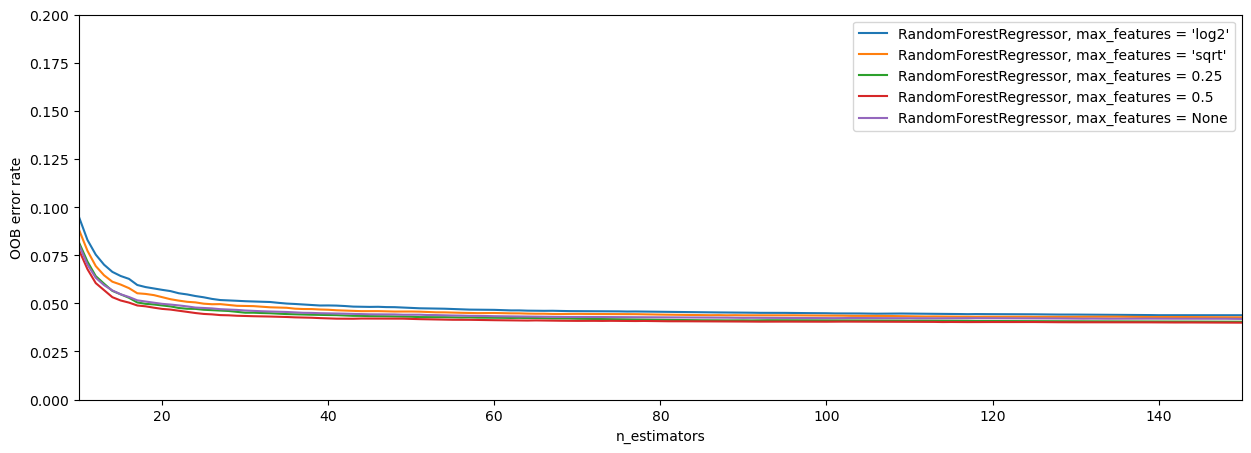

In [104]:
logging.info('warn')

# NOTE: Setting the `warm_start` construction parameter to `True` disables
# support for parallelized ensembles but is necessary for tracking the OOB
# error trajectory during training.
ensemble_clfs = [
    ("RandomForestRegressor, max_features = 'log2'",
        RandomForestRegressor(
            warm_start = True, 
            oob_score = True,
            max_features = "log2",
            random_state = 42)),
    ("RandomForestRegressor, max_features = 'sqrt'",
        RandomForestRegressor(
            warm_start = True, 
            oob_score = True,
            max_features = "sqrt",
            random_state = 42)),
    ("RandomForestRegressor, max_features = 0.25",
        RandomForestRegressor(
            warm_start = True, 
            oob_score = True,
            max_features = 0.25,
            random_state = 42)),
    ("RandomForestRegressor, max_features = 0.5",
        RandomForestRegressor(
            warm_start = True, 
            oob_score = True,
            max_features = 0.5,
            random_state = 42)),
    ("RandomForestRegressor, max_features = None",
        RandomForestRegressor(
            warm_start = True, 
            oob_score = True,
            max_features = None,
            random_state = 42)),
]

# Map a classifier name to a list of (<n_estimators>, <error rate>) pairs.
error_rate = OrderedDict((label, []) for label, _ in ensemble_clfs)

# Range of `n_estimators` values to explore.
min_estimators = 10
max_estimators = 150

for label, clf in ensemble_clfs:
    for i in range(min_estimators, max_estimators + 1):
        clf.set_params(n_estimators = i)
        clf.fit(X_small, y_small)

        # Record the OOB error for each `n_estimators=i` setting.
        oob_error = 1 - clf.oob_score_
        error_rate[label].append((i, oob_error))

# Generate the "OOB error rate" vs. "n_estimators" plot.
plt.figure(figsize = (15, 5))
for label, clf_err in error_rate.items():
    xs, ys = zip(*clf_err)
    plt.plot(xs, ys, label = label)

# Show the plot
plt.xlim(min_estimators, max_estimators)
plt.ylim(0., 0.2)
plt.xlabel("n_estimators")
plt.ylabel("OOB error rate")
plt.legend(loc = "upper right")
plt.show()

In [105]:
model = RandomForestRegressor(
    n_estimators = 40, 
    criterion = 'squared_error', 
    
    # stoping criteria
    max_depth = 15,
    min_samples_split = 2, 
    min_samples_leaf = 1,
    min_weight_fraction_leaf = 0.0, 
    max_leaf_nodes = None, 
    min_impurity_decrease = 0.0, 
    ccp_alpha = 0.0, 
 
    # bagging parameters
    max_features = None, 
    bootstrap = True,
    oob_score = True, 
    max_samples = None,
    
    # other
    warm_start = False, 
    n_jobs = -1,
    random_state = 42,
    verbose = 0, 
)

%time model.fit(X_train, y_train)
print_score(model, X_train, y_train, X_valid, y_valid)

CPU times: total: 1min 56s
Wall time: 10.7 s
RMSE on train set: 761.9683
RMSE on valid set: 1421.4486
R^2 on train set: 0.9882
R^2 on valid set: 0.9583
R^2 on oob set: 0.9593


In [106]:
model = RandomForestRegressor(
    n_estimators = 40, 
    criterion = 'squared_error', 
    
    # stoping criteria
    max_depth = 15,
    min_samples_split = 2, 
    min_samples_leaf = 1,
    min_weight_fraction_leaf = 0.0, 
    max_leaf_nodes = None, 
    min_impurity_decrease = 0.0, 
    ccp_alpha = 0.0, 
 
    # bagging parameters
    max_features = 0.5, 
    bootstrap = True,
    oob_score = True, 
    max_samples = None,
    
    # other
    warm_start = False, 
    n_jobs = -1,
    random_state = 42,
    verbose = 0, 
)

%time model.fit(X_train, y_train)
print_score(model, X_train, y_train, X_valid, y_valid)

CPU times: total: 58.1 s
Wall time: 5.57 s
RMSE on train set: 762.1206
RMSE on valid set: 1322.2015
R^2 on train set: 0.9882
R^2 on valid set: 0.9639
R^2 on oob set: 0.9608


In [107]:
model = RandomForestRegressor(
    n_estimators = 100,
    min_samples_split = 10,
    max_features = 0.5, # default = None
    n_jobs = -1, 
    random_state = 42,
    
    bootstrap = True,
    oob_score = True, # default = False
    max_samples = 0.75, # default = None
)

%time model.fit(X_small, y_small)
print_score(model, X_small, y_small, X_valid, y_valid)

CPU times: total: 1min 7s
Wall time: 6.13 s
RMSE on train set: 861.5926
RMSE on valid set: 1427.3278
R^2 on train set: 0.9847
R^2 on valid set: 0.9579
R^2 on oob set: 0.9586


In [108]:
model = RandomForestRegressor(
    n_estimators = 100,
    min_samples_split = 15,
    max_features = 0.75, # default = None
    n_jobs = -1, 
    random_state = 42,
    
    bootstrap = True,
    oob_score = True, # default = False
    max_samples = 0.75, # default = None
)

%time model.fit(X_train, y_train)
print_score(model, X_train, y_train, X_valid, y_valid)

CPU times: total: 3min 53s
Wall time: 20.6 s
RMSE on train set: 898.3095
RMSE on valid set: 1344.7256
R^2 on train set: 0.9835
R^2 on valid set: 0.9627
R^2 on oob set: 0.9616


In [109]:
model = RandomForestRegressor(
    n_estimators = 150,
    min_samples_split = 10,
    max_features = 0.5, # default = None
    n_jobs = -1, 
    random_state = 42,
    
    bootstrap = True,
    oob_score = True, # default = False
    max_samples = 0.75, # default = None
)

%time model.fit(X_train, y_train)
print_score(model, X_train, y_train, X_valid, y_valid)

CPU times: total: 4min 17s
Wall time: 23.2 s
RMSE on train set: 816.0126
RMSE on valid set: 1306.4159
R^2 on train set: 0.9864
R^2 on valid set: 0.9648
R^2 on oob set: 0.9631


In [110]:
# native Random Forest
model = RandomForestRegressor(
    n_estimators = 100,
    min_samples_split = 2,
    max_features = 0.5, # default = None
    n_jobs = -1, 
    random_state = 42,
    
    bootstrap = True,
    oob_score = True, # default = False 
    max_samples = None,
)

%time model.fit(X_small, y_small)
print_score(model, X_small, y_small, X_valid, y_valid)

CPU times: total: 1min 39s
Wall time: 8.74 s
RMSE on train set: 519.7164
RMSE on valid set: 1382.1062
R^2 on train set: 0.9944
R^2 on valid set: 0.9606
R^2 on oob set: 0.9596


In [111]:
# Random Forest built using the Bagging meta-model
base_model = DecisionTreeRegressor(
    criterion = 'squared_error',
    splitter = 'best', 
    max_depth = None,
    min_samples_split = 2, 
    min_samples_leaf = 1,
    min_weight_fraction_leaf = 0.0, 
    max_features = None, 
    max_leaf_nodes = None, 
    min_impurity_decrease = 0.0, 
    ccp_alpha = 0.0,
    random_state = 42,
)

model = BaggingRegressor(
    estimator = base_model, 
    n_estimators = 100, 

    max_features = 0.5, 
    max_samples = 1.0, 
    
    bootstrap = True, 
    bootstrap_features = False, 
    oob_score = True, 
    
    warm_start = False, 
    n_jobs = -1, 
    random_state = 42, 
    verbose = 0,
)

%time model.fit(X_small, y_small)
print_score(model, X_small, y_small, X_valid, y_valid)

CPU times: total: 2.31 s
Wall time: 10.9 s
RMSE on train set: 538.8793
RMSE on valid set: 1426.1733
R^2 on train set: 0.9940
R^2 on valid set: 0.9580
R^2 on oob set: 0.9566


In [112]:
from sklearn.linear_model import LinearRegression
from sklearn.neural_network import MLPRegressor

In [113]:
# Bagged model using Linear Regression as base model
base_model = LinearRegression()

model = BaggingRegressor(
    estimator = base_model, 
    n_estimators = 100, 

    max_features = 0.5, 
    max_samples = 1.0, 
    
    bootstrap = True, 
    bootstrap_features = False, 
    oob_score = True, 
    
    warm_start = False, 
    n_jobs = -1, 
    random_state = 42, 
    verbose = 0,
)

%time model.fit(X_small, y_small)
print_score(model, X_small, y_small, X_valid, y_valid)

CPU times: total: 875 ms
Wall time: 2 s
RMSE on train set: 3701.0368
RMSE on valid set: 3661.8266
R^2 on train set: 0.7168
R^2 on valid set: 0.7232
R^2 on oob set: 0.7164


In [114]:
# Bagged model using Linear Regression as base model
base_model = MLPRegressor(hidden_layer_sizes = (100, 50), activation = 'tanh')

model = BaggingRegressor(
    estimator = base_model, 
    n_estimators = 10, 

    max_features = 0.5, 
    max_samples = 1.0, 
    
    bootstrap = True, 
    bootstrap_features = False, 
    oob_score = True, 
    
    warm_start = False, 
    n_jobs = -1, 
    random_state = 42, 
    verbose = 0,
)

%time model.fit(X_small, y_small)
print_score(model, X_small, y_small, X_valid, y_valid)

CPU times: total: 1.14 s
Wall time: 1min
RMSE on train set: 7477.2531
RMSE on valid set: 7507.5960
R^2 on train set: -0.1559
R^2 on valid set: -0.1634
R^2 on oob set: -0.1622


In [115]:
# native Random Forest
model = RandomForestRegressor(
    n_estimators = 100,
    min_samples_split = 2,
    max_features = None,
    n_jobs = -1, 
    random_state = 42,
    
    bootstrap = True,
    oob_score = True, # default = False
    max_samples = None,
)

In [116]:
# default is cv = 5
scores = cross_val_score(model, X_small, y_small, cv = 8, n_jobs = -1)

print(scores)
print("r2 is {:.3f} with a standard deviation of {:.3f}".format(scores.mean(), scores.std()))

[0.95648768 0.96183502 0.95927737 0.96233889 0.95992218 0.95444002
 0.95476168 0.9543597 ]
r2 is 0.958 with a standard deviation of 0.003


In [117]:
# randomized splitting strategy
cv = KFold(n_splits = 8, shuffle = True, random_state = 42)

scores = cross_val_score(model, X_small, y_small, cv = cv, n_jobs = -1)

print(scores)
print("r2 is {:.3f} with a standard deviation of {:.3f}".format(scores.mean(), scores.std()))

[0.95396922 0.95531621 0.95832326 0.95058006 0.96260186 0.9651166
 0.96003777 0.95919237]
r2 is 0.958 with a standard deviation of 0.004


In [118]:
# native Random Forest
model = RandomForestRegressor(
    n_estimators = 100,
    max_depth = 3, 
    min_samples_split = 2,
    max_features = None,
    n_jobs = -1, 
    random_state = 42,
    
    bootstrap = True,
    oob_score = True, # default = False
    max_samples = None,
)


# randomized splitting strategy
cv = KFold(n_splits = 5, shuffle = True, random_state = 42)

scores = cross_val_score(model, X_small, y_small, cv = cv, n_jobs = -1)
print(scores)
print("r2 is {:.3f} with a standard deviation of {:.3f}".format(scores.mean(), scores.std()))

[0.82311508 0.84523455 0.8412325  0.85525442 0.85197126]
r2 is 0.843 with a standard deviation of 0.011


In [119]:
# native Random Forest
model = RandomForestRegressor(
    n_estimators = 100,
    max_depth = 10, 
    min_samples_split = 2,
    max_features = None,
    n_jobs = -1, 
    random_state = 42,
    
    bootstrap = True,
    oob_score = True, # default = False
    max_samples = None,
)


# randomized splitting strategy
cv = KFold(n_splits = 5, shuffle = True, random_state = 42)

scores = cross_val_score(model, X_small, y_small, cv = cv, n_jobs = -1)
print(scores)
print("r2 is {:.3f} with a standard deviation of {:.3f}".format(scores.mean(), scores.std()))

[0.94616371 0.94887531 0.9483276  0.95664724 0.95258378]
r2 is 0.951 with a standard deviation of 0.004


In [120]:
# native Random Forest
model = RandomForestRegressor(
    n_estimators = 100,
    max_depth = 20, 
    min_samples_split = 2,
    max_features = None,
    n_jobs = -1, 
    random_state = 42,
    
    bootstrap = True,
    oob_score = True, # default = False
    max_samples = None,
)


# randomized splitting strategy
cv = KFold(n_splits = 5, shuffle = True, random_state = 42)

scores = cross_val_score(model, X_small, y_small, cv = cv, n_jobs = -1)
print(scores)
print("r2 is {:.3f} with a standard deviation of {:.3f}".format(scores.mean(), scores.std()))

[0.95279873 0.95516549 0.95536112 0.96320518 0.95940848]
r2 is 0.957 with a standard deviation of 0.004


In [121]:
scores = cross_val_score(model, X_small, y_small, cv = 8, scoring = 'r2', n_jobs = -1)

print(scores)
print("r2 is {:.3f} with a standard deviation of {:.3f}".format(scores.mean(), scores.std()))

[0.95674156 0.96204015 0.95933239 0.96260354 0.95989926 0.95486459
 0.95414652 0.95408198]
r2 is 0.958 with a standard deviation of 0.003


In [122]:
scores = cross_val_score(model, X_small, y_small, cv = 8, scoring = 'neg_root_mean_squared_error', n_jobs = -1)

print(scores)
print("RMSE is {:.3f} with a standard deviation of {:.3f}".format(-scores.mean(), scores.std()))

[-1472.24280634 -1326.77138189 -1438.05199954 -1358.41167794
 -1368.71900105 -1422.2005345  -1501.38051835 -1508.29638752]
RMSE is 1424.509 with a standard deviation of 63.670


In [123]:
model.get_params()

{'bootstrap': True,
 'ccp_alpha': 0.0,
 'criterion': 'squared_error',
 'max_depth': 20,
 'max_features': None,
 'max_leaf_nodes': None,
 'max_samples': None,
 'min_impurity_decrease': 0.0,
 'min_samples_leaf': 1,
 'min_samples_split': 2,
 'min_weight_fraction_leaf': 0.0,
 'monotonic_cst': None,
 'n_estimators': 100,
 'n_jobs': -1,
 'oob_score': True,
 'random_state': 42,
 'verbose': 0,
 'warm_start': False}

In [124]:
# several grids can be cast into a list
# here we provide only one grid
param_grid = [
    {'n_estimators': [5, 10],
     'max_depth': [10, 20, None],
     'min_samples_split': [2, 10],
     'max_features': [0.4, 0.75, 1.],
     'max_samples': [0.4, 0.75, 1.],
    },
]

model = RandomForestRegressor(
    random_state = 42,
    bootstrap = True,
)

In [125]:
tuned_model = GridSearchCV(
    estimator = model, 
    param_grid = param_grid, 
    scoring = None, # uses estimator's default score method
    n_jobs = -1, 
    refit = True, # keep a fitted version of the overall best model
    cv = 5, 
    return_train_score = True,
    verbose = 2,
)

In [126]:
tuned_model.fit(X_small, y_small)

Fitting 5 folds for each of 108 candidates, totalling 540 fits


,estimator,RandomForestR...ndom_state=42)
,param_grid,"[{'max_depth': [10, 20, ...], 'max_features': [0.4, 0.75, ...], 'max_samples': [0.4, 0.75, ...], 'min_samples_split': [2, 10], ...}]"
,scoring,None
,n_jobs,-1
,refit,True
,cv,5
,verbose,2
,pre_dispatch,'2*n_jobs'
,error_score,nan
,return_train_score,True
,n_estimators,10


In [127]:
best_model = tuned_model.best_estimator_
best_model

,n_estimators,10
,criterion,'squared_error'
,max_depth,20
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,0.4
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


In [128]:
print_score(best_model, X_small, y_small, X_valid, y_valid)

RMSE on train set: 640.0838
RMSE on valid set: 1461.4264
R^2 on train set: 0.9915
R^2 on valid set: 0.9559


In [129]:
# randomized splitting strategy
cv = KFold(n_splits = 5, shuffle = True, random_state = 42)

scores = cross_val_score(best_model, X_small, y_small, cv = cv, n_jobs = -1)

print(scores)
print("r2 is {:.3f} with a standard deviation of {:.3f}".format(scores.mean(), scores.std()))

[0.94819145 0.95051188 0.95166795 0.95640432 0.95463746]
r2 is 0.952 with a standard deviation of 0.003


In [130]:
import joblib

joblib.dump(best_model, 'best_model.joblib')

['best_model.joblib']